In [1]:
import os
import math
import cartopy.crs as ccrs
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import colormaps as cm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mpl_cm

from graphcast.losses import normalized_latitude_weights
from omegaconf import OmegaConf

import graphufs
from graphufs.datasets import Dataset
from graphufs.lineplot import LinePlotter
from graphcast.model_utils import stacked_to_dataset
from graphufs.stacked_utils import get_channel_index

# this may need to be changed later
from prototypes.ocn_only.emulator import OcnEvaluator, OcnTrainer

In [2]:
plt.style.use("graphufs.plotstyle")

In [3]:
def persistence_fcast(model_type:str, prototype:str, eval_dates:list[str], num_missing_samples:int, fcast_nhours="240h"):

    #### SETUP ####
    emulator = OcnEvaluator(prototype)
    preserved_dims = ("batch", "lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the validation data
    valid_dir = f"{emulator.local_store_path}/validation"
    validation_inputs = xr.open_zarr(f"{valid_dir}/inputs.zarr")["inputs"] # (sample, lat, lon, channels)

    # Calculate the date ranges and find the integer indices for slicing
    validation_datetime = pd.date_range(
        start=pd.to_datetime(emulator.validation_dates[0]),
        end=(pd.to_datetime(emulator.validation_dates[1]) - 
             pd.Timedelta(emulator.delta_t_model)) - num_missing_samples*pd.Timedelta(emulator.delta_t_data),
        freq=pd.Timedelta(emulator.delta_t_data),
        inclusive="both",
    )
    
    # check the length of the validation dataset = validation datetime
    assert len(validation_datetime)==validation_inputs.sizes["sample"], \
    f"Error: Length of the time stamp vector and validation inputs did not match: {len(validation_datetime)}, {validation_inputs.sizes['sample']}"

    idx_start = validation_datetime.get_loc(pd.to_datetime(eval_dates[0]))
    idx_end = validation_datetime.get_loc(pd.to_datetime(eval_dates[1]))

    # Select the evaluation data and rename 'sample' to 'batch' for consistency
    eval_inputs = validation_inputs.sel(sample=slice(idx_start, idx_end, emulator.sample_stride)
    ).rename({"sample": "batch"}) # (batch=292, lat, lon, channels)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )
    
    # assert the lengths of the eval datetime vector and the eval dataset
    assert len(eval_datetime)==eval_inputs.sizes["batch"], \
    f"Error: Length of the eval datetime vector and eval inputs did not match:" \
    f"{len(eval_datetime)}, {eval_inputs.sizes['batch']}"

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
    meta_xinputs = get_channel_index(xinputs)

    for variable in xinputs.data_vars:
        dims_to_ensure = preserved_dims #tuple(d for d in preserved_dims if d != "batch")
        dims_not_present = [d for d in dims_to_ensure if d not in xinputs[variable].dims]
        for dimen in dims_not_present:
            xinputs[variable] = xinputs[variable].expand_dims(dim={dimen:eval_inputs.coords[dimen]})
        # make sure that the batch dimension has the same size in both datasets. Actually all
        # preserved dims must have the same size in both.
        if xinputs.sizes["batch"] != eval_inputs.sizes["batch"]:
            xinputs = xinputs.reindex({"batch":eval_inputs.coords["batch"]}, method="pad")
        xinputs[variable] = xinputs[variable].transpose("batch", ..., "lat", "lon")

    #### UNSTACK VALIDATION DATA ####
    # Only consider the input channels, not forcing. Note that xinputs would not have
    # forcing channels appended at the end. Just choose the inputs because the mapping
    # is only for inputs and this is what we need essentially.
    eval_inputs = eval_inputs.isel(channels=slice(None, len(meta_xinputs)))

    # Unstack the data by passing the underlying .variable object
    eval_inputs_unstacked = stacked_to_dataset(eval_inputs.variable, 
                                               xinputs, preserved_dims=preserved_dims)
    
    # now return the persistence in the same form as targets
    ds_persistence_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    for variable in xtargets.data_vars:
        var = eval_inputs_unstacked[variable].isel(time=-1, drop=True)
        var = var.rename(batch="time").assign_coords(time=eval_datetime)
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_persistence_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_persistence_fcast

In [4]:
def climatology_fcast(model_type:str, prototype:str, eval_dates:list[str], fcast_nhours="240h"):

    print("forecast nhours:", fcast_nhours)
    #### SETUP ####
    ocn_only_home = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
    preserved_dims = ("lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the training data
    train_dir = f"{emulator.local_store_path}/training"
    training_targets = xr.open_zarr(f"{train_dir}/targets.zarr")["targets"] # (sample, lat, lon, channels)

    # climatology
    climatology = training_targets.mean(dim="sample") # (lat, lon, channels)

    #### PREPARE THE TEMPLATE DATASET ####
    
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)

    #### UNSTACK CLIMATOLOGY ####
    clima_unstacked = stacked_to_dataset(climatology.variable, 
                                         xtargets.isel(batch=0, time=0, drop=True), 
                                         preserved_dims=preserved_dims)
    
    # now return the persistence in the same form as targets
    ds_clima_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    print("fcast_nhours:", fcast_nhours)
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]) - pd.Timedelta(emulator.delta_t_model),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )
    
    for variable in xtargets.data_vars:
        var = clima_unstacked[variable]
        var = var.expand_dims(dim={"time": eval_datetime})
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_clima_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_clima_fcast

In [5]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        print("num of missing samples:", num_missing_samples )
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [6]:
def calculate_sq_error_for_model(model_pred, ref_truth):
    """
    Calculates sq_error for a given model against a truth reference.
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    sq_error_vars = {}

    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute error and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask
        
        sq_error_vars[var] = error**2
        
    return sq_error_vars

In [7]:
def calculate_rmse(sqerr_da, apply_weighting=False, depth_level=0, 
                   depth_unit="dimensionless"):
    """
    Calculates the Root Mean Squared Error from a squared error DataArray.
    
    This function correctly preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in sqerr_da.dims:
        if depth_unit.lower() == "dimensionless": 
            sqerr_da = sqerr_da.isel(z_l=depth_level)
        else:
            sqerr_da = sqerr_da.sel(z_l=depth_level, method="nearest")
            
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(sqerr_da)
        sqerr_da = sqerr_da * weights.astype(sqerr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    # The 'time' dimension (or 'init_time') holds the samples for the CI.
    dims_to_avg = [dim for dim in sqerr_da.dims if dim not in ["lead_time", "time"]]
    
    # Calculate the mean over spatial dimensions and take the square root
    rmse_da = np.sqrt(sqerr_da.mean(dim=dims_to_avg))
    
    return rmse_da

## Setup the meta and compute RMSE

In [8]:
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
SAMPLE_STRIDE = 5

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-Maha",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
    {
        "name": "Persistence-24h",
        "type": "persistence",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "",
        "pred_prefix": "persistence",
        "timestep": "24h",
        "duration": "240h",
        "description": "persistence",
        "num_missing_samples": 0, # or, 3
    }
]

In [9]:
# ---- Main computation block ----
# Initialize dictionaries to store all results
all_sq_error = {}
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")
        
    all_sq_error[model_name] = {}
        
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate all metrics for this model against this truth
        sq_err = calculate_sq_error_for_model(model_pred, ref_truth)
            
        # Store results
        all_sq_error[model_name][truth_name] = sq_err

print("\n --- Metric calculation complete!! ---")


Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...

Processing Model: Emulator-24h-Maha
Comparing against truth: Replay ...

Processing Model: Persistence-24h
num of missing samples: 0
Comparing against truth: Replay ...

 --- Metric calculation complete!! ---


In [10]:
# units
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

# error bounds
error_bounds = {}
error_bounds["SSH"] = {"vmin":0, "vmax":0.1}  # 0-15 cm
error_bounds["so"] = {"vmin":0, "vmax":0.2}   # 0-0.4 psu
error_bounds["temp"] = {"vmin":0, "vmax":0.6} # 0-0.5 degC
error_bounds["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s

In [11]:
vars_2d = ["SSH"]
vars_3d = list(set(model_pred.data_vars) - set(vars_2d))

In [12]:
def plot_rmse_vs_leadtime_2d(ax, 
                             da: xr.DataArray, 
                             var_name: str = None, 
                             unit: str = None, 
                             timestep: str = "6h", 
                             forecast_days: int = 10, 
                             label: str = "",
                             vmin: float = None,
                             vmax: float = None,
                             show_title: bool = True,
                             apply_latitude_weighting: bool = True):
    """
    Plot RMSE vs lead_time for a 2D variable.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in legend
    - vmin, vmax: RMSE bounds
    """
    # convert lead time to hours/days
    lead_time_hours = da["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days = lead_time_hours / 24

    # subsample to the end of every day
    steps_per_day = int(24 / int(timestep[:-1])) 
    ts_to_plot = np.arange(steps_per_day-1, forecast_days*steps_per_day, steps_per_day)

    # get values to plot
    values = da.values[ts_to_plot]
    days = lead_time_days[ts_to_plot]

    # vmin/vmax
    vmin = vmin if vmin is not None else error_bounds[var_name]["vmin"]
    vmax = vmax if vmax is not None else error_bounds[var_name]["vmax"]

    # plot
    ax.plot(days, values, linewidth=2, label=label,)
    ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = f"Forecast Lead Time [days]"
    ylabel = f"RMSE [{unit}]" if unit is not None else f"RMSE [{units[var_name]}]"
    if apply_latitude_weighting:
        ylabel = f"LW-{ylabel}"
    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)

    # axis ticks
    ax.tick_params(axis="x", labelsize=14,)
    ax.tick_params(axis="y", labelsize=14,)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=16,)
    
    return ax

In [13]:
def plot_spatial_rmse(ax, 
                      da: xr.DataArray, 
                      var_name: str = None, 
                      unit: str = None, 
                      label: str = "",
                      show_title: bool = True,
                      apply_latitude_weighting: bool = True,
                      **kwargs):
    """
    Plot spatial map of RMSE for a given variable and lead time.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - label: label to use in legend
    - vmin, vmax: RMSE bounds
    """

    da.plot(ax=ax, transform=ccrs.PlateCarree(), **kwargs)
    ax.coastlines(alpha=0.5)
    if show_title:
        ax.set_title(label)

    leadtime = pd.to_timedelta(da.lead_time.values, unit="D")
    title = f"RMSE [in {unit}], {var_name}, lead_time={leadtime}"
    if apply_latitude_weighting:
        title = f"LW-{title}"
    plt.suptitle(title)
    
    return ax

In [14]:
def plot_rmse_vs_latitude(ax, 
                          da: xr.DataArray, 
                          var_name: str = None, 
                          unit: str = None, 
                          timestep: str = "6h", 
                          forecast_days: int = 10, 
                          label: str = "",
                          ylabel: str = "",
                          vmin: float = None,
                          vmax: float = None,
                          days_to_plot:list = (1, 2, 4, 6, 8, 10),
                          cmap = mpl_cm.plasma,
                          norm = None, 
                          show_cbar:bool = True,
                          show_title:bool = True,):
    """
    Plot RMSE vs latitudes for specified lead times.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: Name of the variable
    - unit: Unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in title
    - vmin, vmax: RMSE bounds
    - days_to_plot: lead times (in days) to plot
    - cmap: colormap
    - norm: normalized colormap
    """

    # check relevant axes
    if not {"lead_time", "lat"}.issubset(set(da.dims)):
        raise ValueError("Expected 'lead_time' and 'z_l' dimensions")
    
    # setup the plot params
    lats = da["lat"].values
    timestep_int = int(timestep[:-1]) # in hours
    colors = [cmap(norm(day)) for day in days_to_plot]
    
    vmin = vmin or error_bounds.get(var_name, {}).get("vmin", None)
    vmax = vmax or error_bounds.get(var_name, {}).get("vmax", None)

    # plot
    for day, color in zip(days_to_plot, colors):
        lt_idx = int(day * 24 / timestep_int) - 1
        rmse = da.isel(lead_time=lt_idx)
        ax.plot(lats, rmse, label=f"{day} day", color=color,)
        

    # axis ticks and labels
    xlabel = f"Latitude"
    if not ylabel: 
        ylabel = f"RMSE [{unit}]" if unit is not None else "RMSE"
    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)
    ax.set_ylim(vmin, vmax)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}, {label}", fontsize=16,)

    # colorbar for lead time gradient
    if show_cbar:
        sm = mpl_cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cb = plt.colorbar(sm, orientation="vertical", ax=ax, fraction=0.02, pad=0.02,)
        cb.ax.tick_params(labelsize=14)
        cb.set_label(label="Forecast Lead Time [days]", size=14)

    return ax

In [15]:
def plot_rmse_vs_depth(ax, 
                       da: xr.DataArray, 
                       var_name: str = None, 
                       unit: str = None, 
                       timestep: str = "6h", 
                       forecast_days: int = 10, 
                       label: str = "",
                       xlabel: str = "",
                       vmin: float = None,
                       vmax: float = None,
                       days_to_plot=(1, 2, 4, 6, 8, 10),
                       cmap=mpl_cm.plasma,
                       norm=None,
                       show_title: bool = True,
                       show_cbar: bool = True,
                       apply_latitude_weighting: bool = False):
    """
    Plot RMSE vs ocean depth for different lead times.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: Name of the variable
    - unit: Unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in title
    - vmin, vmax: RMSE bounds
    - days_to_plot: lead times (in days) to plot
    - cmap: colormap
    - norm: normalized colormap
    """

    # check relevant axes
    if not {"lead_time", "z_l"}.issubset(set(da.dims)):
        raise ValueError("Expected 'lead_time' and 'z_l' dimensions")
    
    # setup the plot params
    depths = da["z_l"].values
    timestep_int = int(timestep[:-1])
    colors = [cmap(norm(day)) for day in days_to_plot]
    vmin = vmin if vmin is not None else error_bounds[var_name]["vmin"]
    vmax = vmax if vmax is not None else error_bounds[var_name]["vmax"]

    # plot
    for day, color in zip(days_to_plot, colors):
        lt_idx = int(day*24 / timestep_int) - 1
        rmse = da.isel(lead_time=lt_idx)
        ax.plot(rmse, depths, label=f"{day} day", color=color,)
        

    # axis ticks and labels
    #ax.invert_yaxis()
    xlabel = xlabel if xlabel is not None else f"RMSE [{unit}]" if unit is not None else "RMSE"
    if xlabel is None and apply_latitude_weighting:
        xlabel = f"LW-{xlabel}"
    ylabel = f"Depth [m]"
    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)
    ax.set_xlim(vmin, vmax)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}, {label}", fontsize=16,)

    # colorbar
    if show_cbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, orientation="vertical", ax=ax,
                            fraction=0.05, pad=0.02,)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(label="Forecast Lead Time [days]", size=14)
    
    return ax

In [20]:
def plot_depth_vs_leadtime(ax, 
                           da: xr.DataArray, 
                           var_name: str = "Variable", 
                           unit: str = "units", 
                           timestep: str = "6h", 
                           label: str = "",
                           vmin: float = None,
                           vmax: float = None,
                           cmap=mpl_cm.plasma,
                           show_title: bool = True,
                           show_cbar: bool = True,
                           clabel: str = "",):
    """
    Plot Depth vs Lead Time as a heatmap (image plot) with error intensity.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time", "z_l")
    - var_name: Name of the variable
    - unit: Unit of the variable
    - timestep: time step of the forecast (must be in hours, e.g., "6h")
    - label: label to use in title
    - vmin, vmax: Colorbar bounds for the error/variable
    - cmap: colormap
    - show_title: boolean to toggle title
    - show_cbar: boolean to toggle colorbar
    - clabel: colorbar label
    """

    # 1. Check relevant axes
    if not {"lead_time", "z_l"}.issubset(set(da.dims)):
        raise ValueError(f"Expected 'lead_time' and 'z_l' dimensions, found {da.dims}")
    
    # 2. Prepare Coordinate for X-Axis (Lead Time in Days)
    # We convert the raw lead_time index into 'Days' for a readable X-axis.
    timestep_int = int(timestep[:-1]) # e.g., extracts 6 from "6h"
    
    # Formula: Time (days) = (Index + 1) * (Hours per step) / 24
    # We create a new DataArray for plotting to avoid modifying the original 'da' in place
    da_plot = da.copy()
    
    # If lead_time is just indices (0, 1, 2...), generate physical time array
    if np.issubdtype(da.lead_time.dtype, np.integer) or np.issubdtype(da.lead_time.dtype, np.floating):
        days_coord = (np.arange(len(da.lead_time)) + 1) * timestep_int / 24.0
        da_plot = da_plot.assign_coords(lead_time=days_coord)
        xlabel = "Forecast Lead Time [days]"
    else:
        # If lead_time is already a datetime object or similar, use it as is
        xlabel = "Forecast Lead Time"

    # 3. Setup Colorbar Bounds
    # You might want to define default error_bounds dictionary externally or handle here
    # For now, we use the provided vmin/vmax or let matplotlib decide defaults
    if vmin is None: vmin = da_plot.min().item()
    if vmax is None: vmax = da_plot.max().item()

    # 4. Plotting (pcolormesh)
    # x='lead_time' ensures time is on X-axis, y='z_l' ensures depth is on Y-axis
    cbar_kwargs = {"label": clabel} if show_cbar else None
    
    mesh = da_plot.plot.pcolormesh(
        ax=ax,
        x="lead_time",
        y="z_l",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        add_colorbar=show_cbar,
        cbar_kwargs=cbar_kwargs
    )

    # 5. Axis Formatting
    ax.set_ylabel("Depth [m]", fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    
    # Invert Y-axis so the ocean surface (0m) is at the top
    ax.invert_yaxis()

    # 6. Title
    if show_title:
        title_text = f"{var_name}"
        if label:
            title_text += f" ({label})"
        ax.set_title(title_text, fontsize=16)

    return ax

## Plot 2D

model: Emulator-24h-MSE
model: Emulator-24h-Maha
model: Persistence-24h


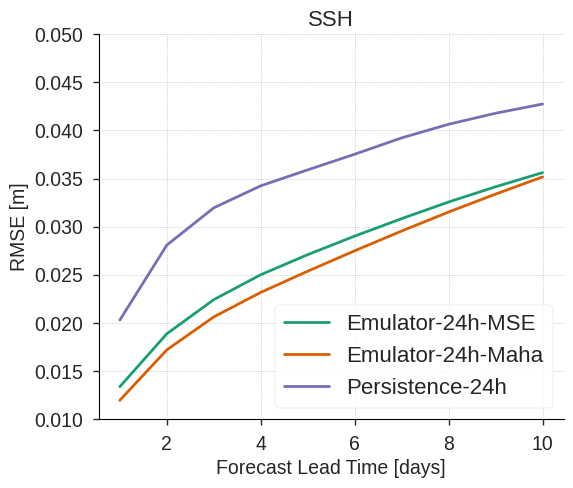

In [44]:
# Plot
n_vars = len(vars_2d)
save_plot = False # remember to change the file name if needed
apply_latitude_weighting = False

# Determine grid size for subplots
ncols = 1
nrows = math.ceil(n_vars / ncols)

for truth in TRUTHS:
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 5 * nrows))
    if ncols*nrows > 1:
        axes = axes.flatten()
    
    for i, var_name in enumerate(vars_2d):
        ax = axes[i] if ncols*nrows > 1 else axes
    
        for model in MODELS_CONFIG:
            print("model:", model['name'])
    
            sqerr = all_sq_error[model['name']][truth][var_name]
            
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)

            # avg over the remaining dims
            dims_to_avg = set(sqerr.dims) - {"lead_time"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            # plot
            _ = plot_rmse_vs_leadtime_2d(
                ax, 
                da, 
                var_name=var_name, 
                unit=units.get(var_name, ""),
                timestep=model['timestep'], 
                forecast_days=10, 
                label=f"{model['name']}",
                vmin=0.01,
                vmax=0.05,
                apply_latitude_weighting = apply_latitude_weighting,
            )

        #ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1)) # Example: top-right outside)
        ax.legend()
    
        # Hide extra axes if any
        if ncols*nrows != 1:
            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            
        #plt.tight_layout()

        # save plot
        if save_plot:
            figname = f"RMSE_vs_lead_time_{var_name}_ocnonly_6h_24h_euclid_persist_climatology_against_{truth}.jpeg"
            if apply_latitude_weighting:
                figname = f"LW-{figname}"
            plt.savefig(f"./figures/{figname}", dpi=300)
        
    plt.show()

# Spatial RMSE Plot

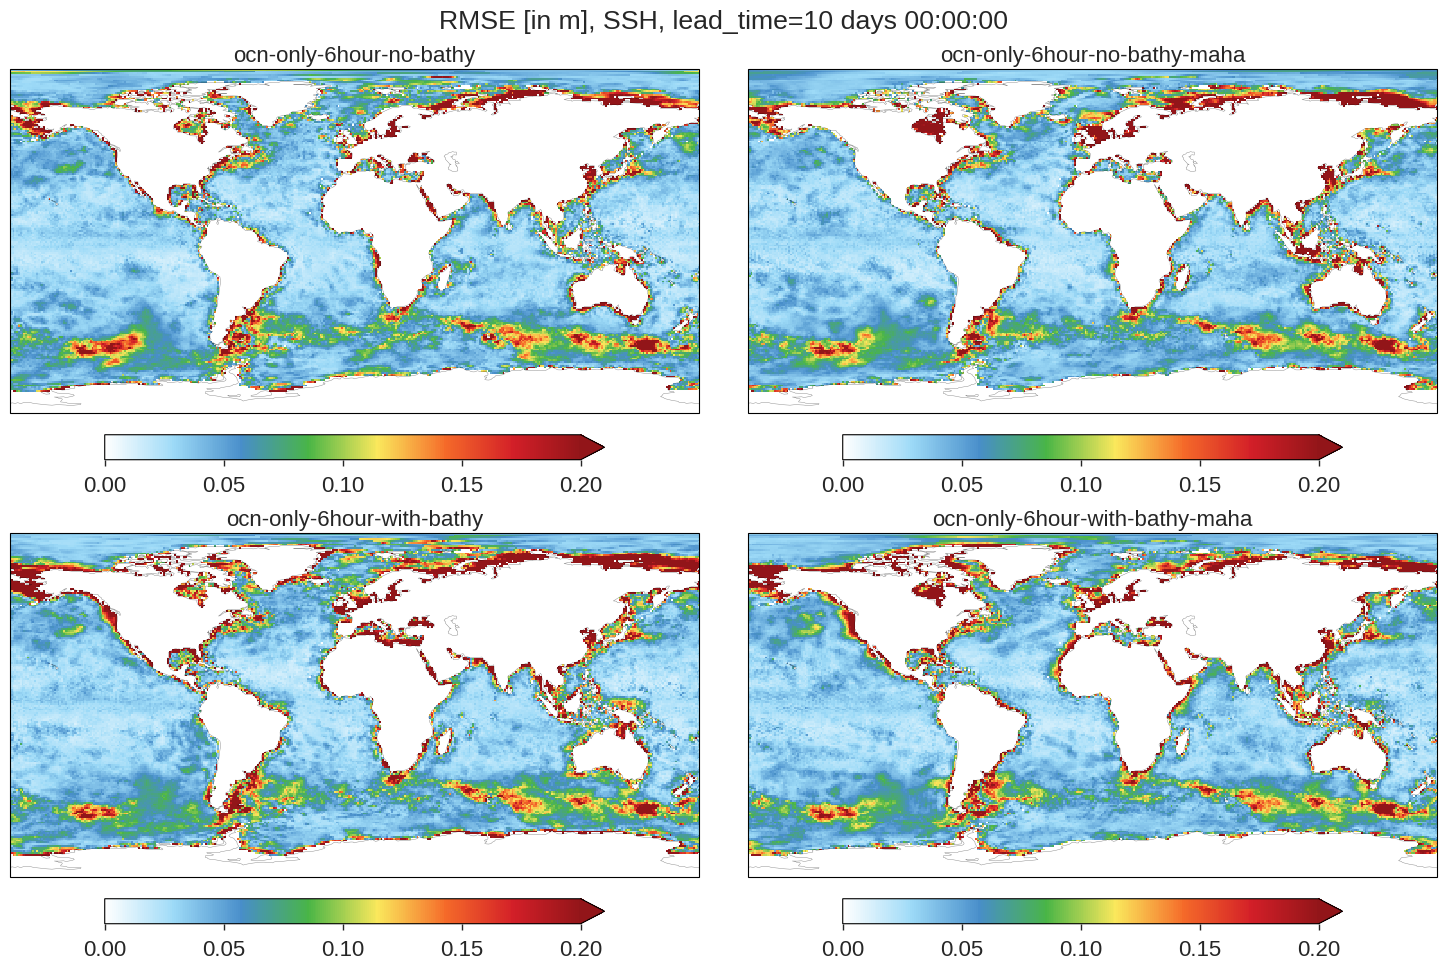

In [18]:
n_vars = len(vars_2d)
save_plot = True # remember to change the file name if needed
apply_latitude_weighting = False
lead_time = 10 # in days
lead_time_to_plot = pd.to_timedelta(lead_time, unit='D')

# Determine grid size for subplots
n_tot = len(models)
ncols = 2
nrows = math.ceil(n_tot / ncols)

for truth in truths:

    for var_name in vars_2d:
    
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7.5 * ncols, 5 * nrows), 
                                 subplot_kw=dict(projection=ccrs.PlateCarree()))

        if ncols*nrows > 1:
            axes = axes.flatten()
    
        for i, model in enumerate(models):
            ax = axes[i] if ncols*nrows > 1 else axes
        
            model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
            model_name = model.replace(" ", "_")
    
       
            sqerr = sq_error[model_name][truth][var_name]
            sqerr = sqerr.sel(lead_time=lead_time_to_plot)
            
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)

            # avg over the remaining dims
            dims_to_avg = set(sqerr.dims) - {"lead_time","lat","lon"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            kwargs = {"cbar_kwargs":{"orientation": "horizontal", "shrink":0.7, "pad":0.05}, 
                      "robust":True, "cmap":cm.WhiteBlueGreenYellowRed, **error_bounds[var_name],}

            # plot
            _ = plot_spatial_rmse(
                ax, 
                da, 
                var_name=var_name, 
                unit=units.get(var_name, ""),
                label=f"{model_type}-{descrip}",
                apply_latitude_weighting = apply_latitude_weighting,
                **kwargs
            )

    
        # Hide extra axes if any
        if ncols*nrows > 1:
            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            
        plt.tight_layout()

        # save plot
        if save_plot:
            figname = f"RMSE_{lead_time}days_{var_name}_ocnonly_{model_time_step}_bathy-vs-nobathy_euclid-vs-maha_against_{truth}.jpeg"
        if apply_latitude_weighting:
            figname = f"LW-{figname}"
        plt.savefig(f"./figures/{figname}", dpi=300)
        
        plt.show()

## Error as a function of the latitude 

#### Note that no latitude weighting will be applied here to the errors irrespective of the value of the boolean parameter "apply_latitude_weighting", otherwise errors would be latitude independent.

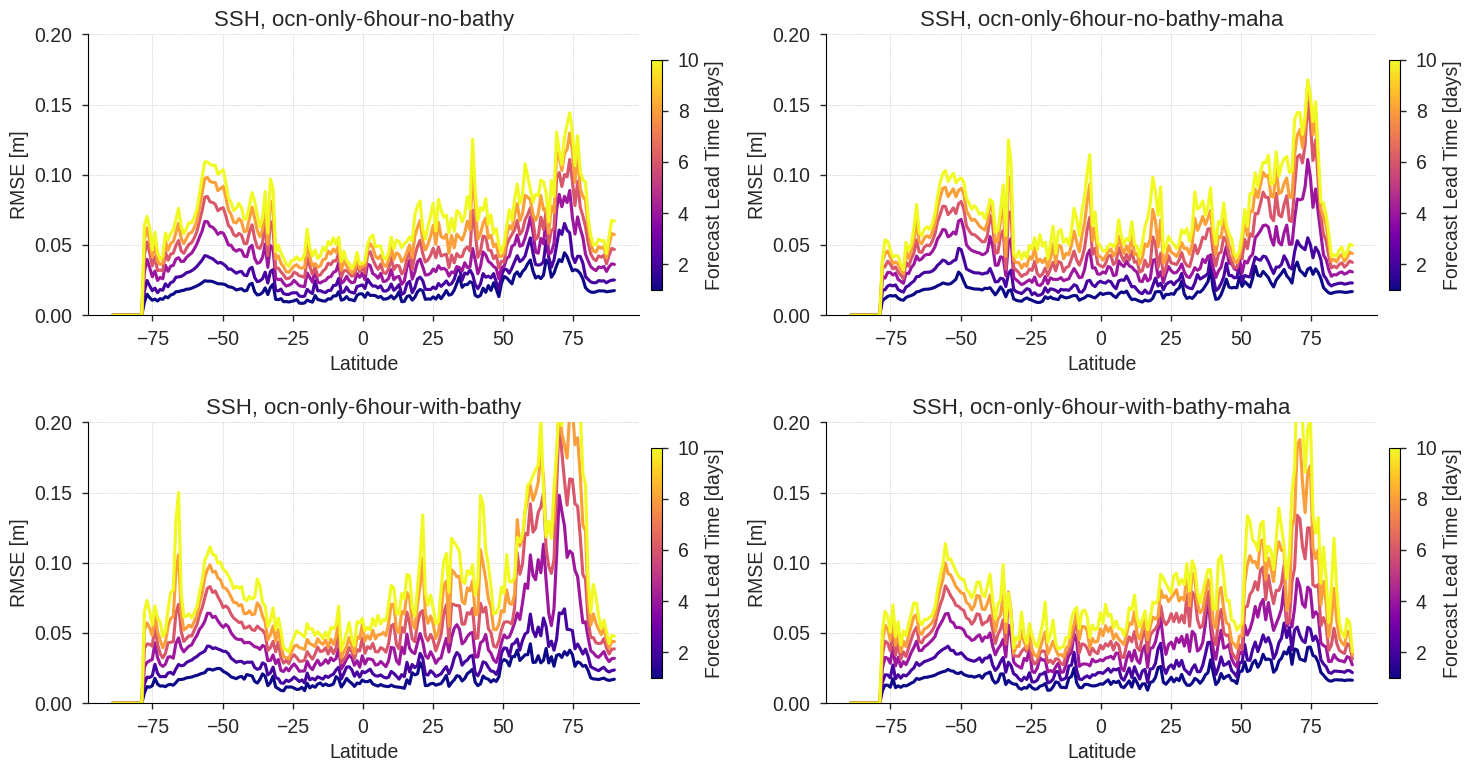

In [19]:
n_vars = len(vars_2d)
n_tot = len(models)
ncols = 2
nrows = math.ceil(n_tot / ncols)
save_plot = True

# Lead times for which to plot RMSE lines
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = mpl_cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for truth in truths:

    for idx, var_name in enumerate(vars_2d):

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7.5 * ncols, 4 * nrows), squeeze=False)
        axes = axes.flatten()
        
        for i, model in enumerate(models):
            ax = axes[i]
            model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
            model_name = model.replace(" ", "_")

            # Compute RMSE, averaged over all non-lead_time/lat dims
            da = sq_error[model_name][truth][var_name]
            dims_to_avg = set(da.dims) - {"lead_time", "lat"}
            da = np.sqrt(da.mean(dim=dims_to_avg))

            _ = plot_rmse_vs_latitude(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10,
                    label=f"{model_type}-{descrip}",
                    cmap=cmap,
                    norm=norm,
                    days_to_plot=days_to_plot,       
            )

        # Remove any unused axes
        for idx in range(len(models), nrows * ncols):
            fig.delaxes(axes[idx])

        #fig.suptitle(f"RMSE vs Latitude for {model_name} vs {truth}", fontsize=14)
        plt.tight_layout()

        # Save plot
        if save_plot:
            figname = f"RMSE_vs_latitude_{var_name}_ocnonly_{model_time_step}_bathy-vs-nobathy_euclid-vs-maha_against_{truth}.jpeg"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

## Plot the normalized RMSE diff with one model as a reference, so that the others are easier to interpret. This is similar to what is used in GraphCast.

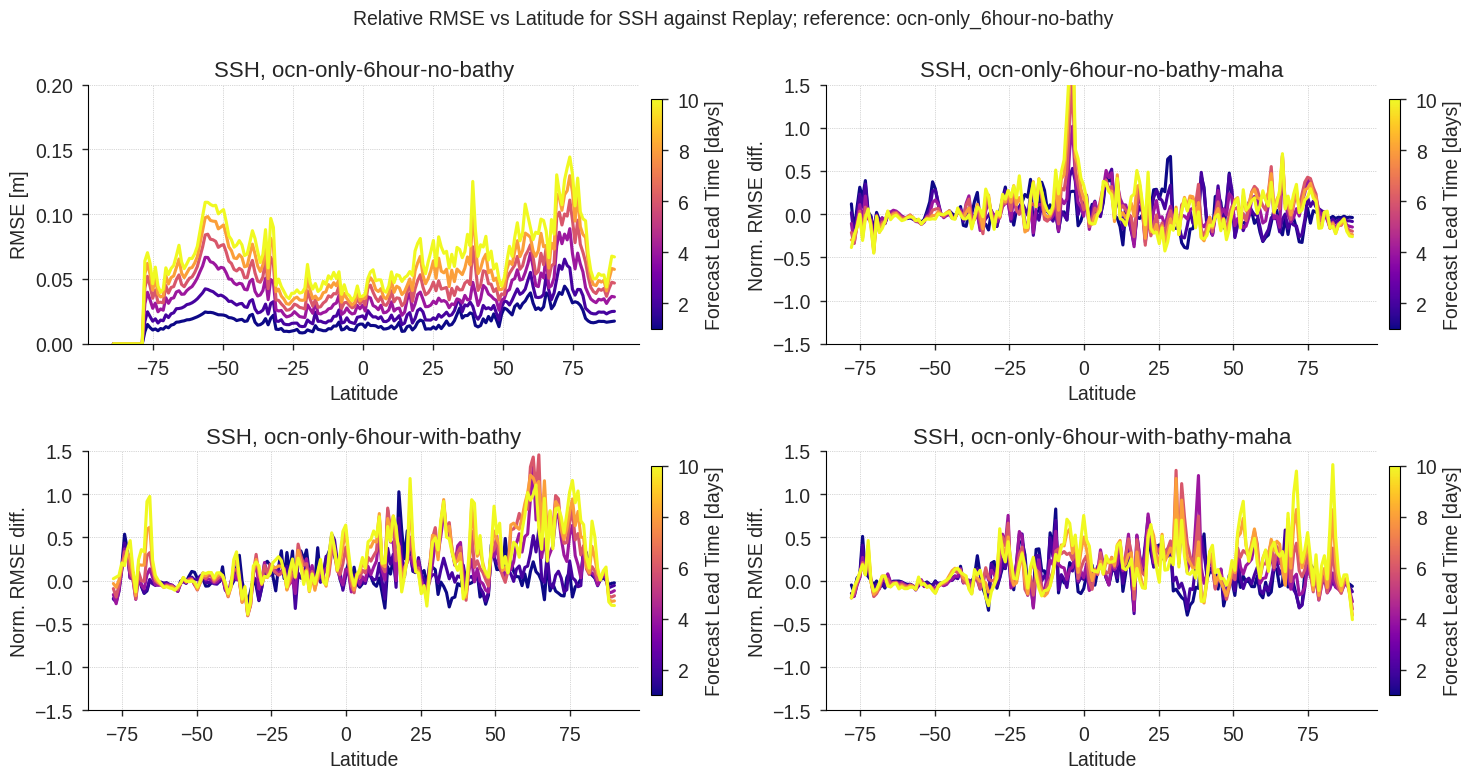

In [20]:
n_vars = len(vars_2d)
n_tot = len(models)
ncols = 2
nrows = math.ceil(n_tot / ncols)
save_plot = True

# Lead times for which to plot RMSE lines
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = mpl_cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

reference_model = models[0].replace(" ", "_")

for truth in truths:

    for idx, var_name in enumerate(vars_2d):

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7.5 * ncols, 4 * nrows), squeeze=False)
        if nrows*ncols > 1:
            axes = axes.flatten()
        
        for i, model in enumerate(models):
            ax = axes[i] if nrows*ncols > 1 else axes
            model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
            model_name = model.replace(" ", "_")

            # Compute RMSE, averaged over all non-lead_time/lat dims
            da = sq_error[model_name][truth][var_name]
            dims_to_avg = set(da.dims) - {"lead_time", "lat"}
            da = np.sqrt(da.mean(dim=dims_to_avg))

            if model_name == reference_model:
                da_reference = da
                vmin=0; vmax=0.2 
                ylabel = "RMSE [m]"
            else:
                vmin=-1.5; vmax=1.5
                try:
                    da = (da - da_reference)/da_reference
                except AttributeError as e:
                    print(f"Make sure that the reference model is the first in the models list: {e}")                    
                ylabel = "Norm. RMSE diff."
            _ = plot_rmse_vs_latitude(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    ylabel = ylabel,
                    vmin=vmin, vmax=vmax,
                    forecast_days=10,
                    label=f"{model_type}-{descrip}",
                    cmap=cmap,
                    norm=norm,
                    days_to_plot=days_to_plot,       
            )

        # Remove any unused axes
        for idx in range(len(models), nrows * ncols):
            fig.delaxes(axes[idx])

        reference = reference_model.split("_")
        fig.suptitle(f"Relative RMSE vs Latitude for {var_name} against {truth}; reference: {reference[0]+'_'+reference[-1]} ", fontsize=14)
        plt.tight_layout()

        # Save plot
        if save_plot:
            figname = f"Normalized_RMSE_diff_vs_latitude_{var_name}_ocnonly_{model_time_step}_bathy-vs-nobathy_euclid-vs-maha_against_{truth}.jpeg"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

## Plot 3D

### Plot all four 3D variables for a given model

var_name: so
var_name: temp
var_name: uo
var_name: vo


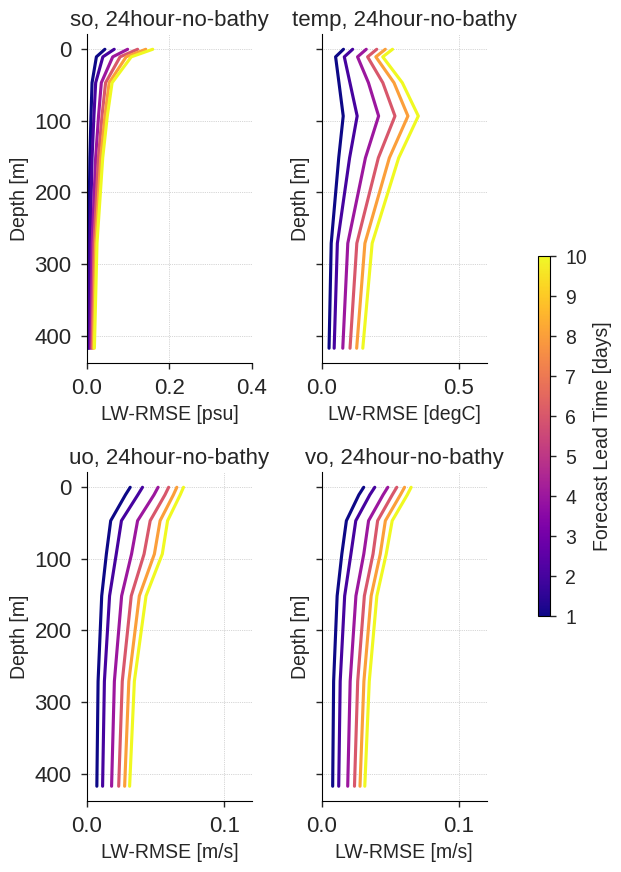

var_name: so
var_name: temp
var_name: uo
var_name: vo


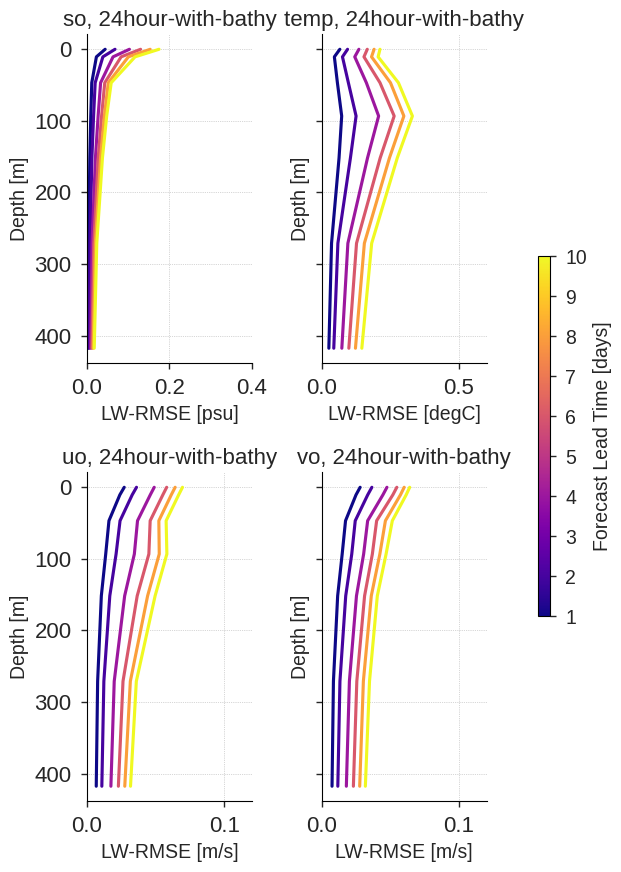

var_name: so
var_name: temp
var_name: uo
var_name: vo


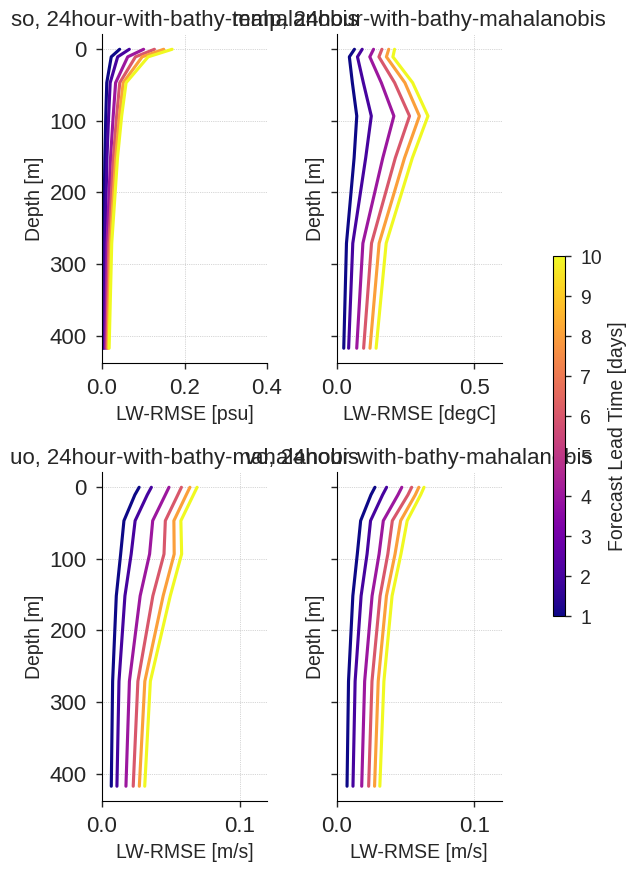

In [10]:
vars_3d.sort()
n_vars = len(vars_3d)
ncols = 2
nrows = math.ceil(n_vars / ncols)
save_plot = True

# Lead times for which to plot RMSE lines
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for model in models:
    model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
    model_name = model.replace(" ", "_")

    for truth in truths:
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols, figsize=(3 * ncols, 4.5 * nrows),
            sharey = "all",
        )

        for idx, var_name in enumerate(vars_3d):
            print("var_name:", var_name)
            ax = axes[idx // ncols][idx % ncols]

            # Compute RMSE, averaged over all non-lead_time/lat dims
            sqerr = sq_error[model_name][truth][var_name]
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))
            ax = plot_rmse_vs_depth(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10,
                    label=f"{descrip}",
                    days_to_plot=days_to_plot,
                    cmap=cmap,
                    norm=norm,
                    show_cbar=False,
            )
            
        ax.invert_yaxis()
        
        # Remove any unused axes
        for idx in range(len(vars_3d), nrows * ncols):
            fig.delaxes(axes[idx // ncols][idx % ncols])

        plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right (90% width)
        
        # Add shared colorbar
        cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time (days)",
                            orientation="vertical", fraction=0.05, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(label="Forecast Lead Time [days]", size=14)

        # Save plot
        if save_plot:
            figname = f"RMSE_vs_depth_{model_name}_against_{truth}.jpeg"
            if apply_latitude_weighting:
                figname = f"LW-{figname}"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

## Normalized RMSE diff for a given variable for all levels and for all models

var_name: so


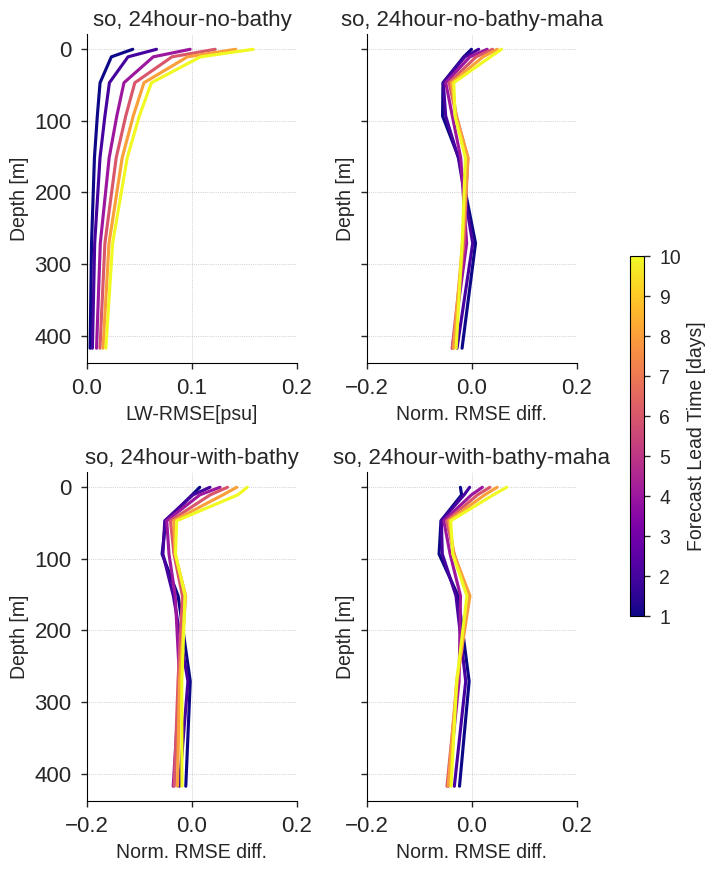

var_name: temp


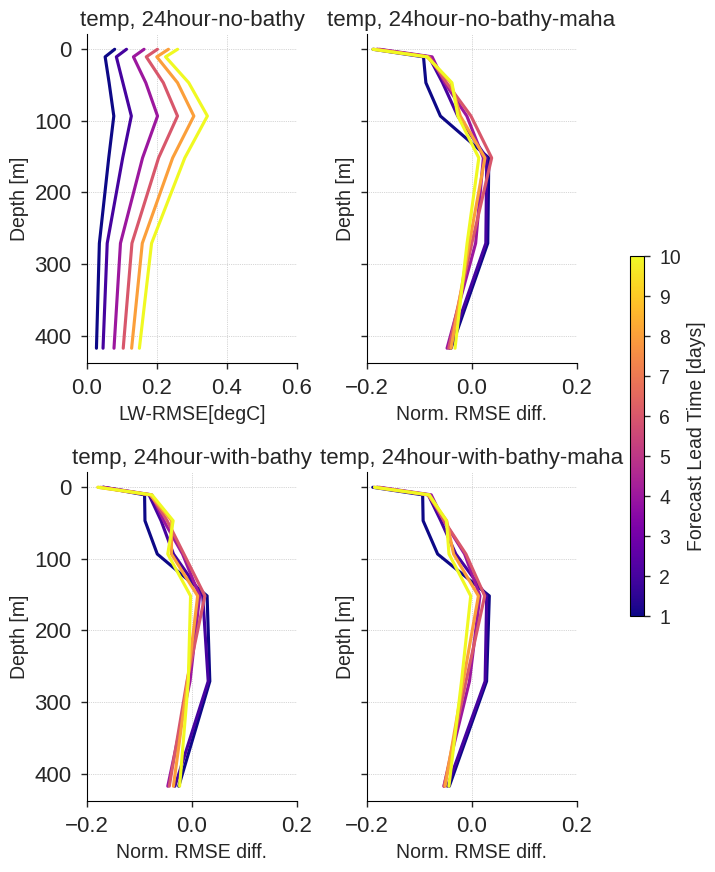

var_name: uo


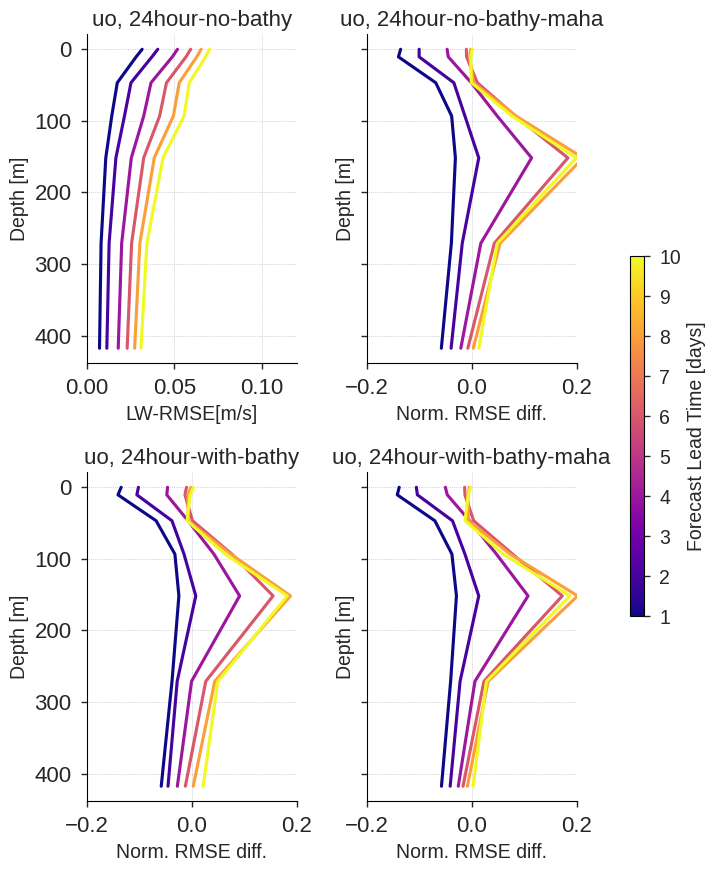

var_name: vo


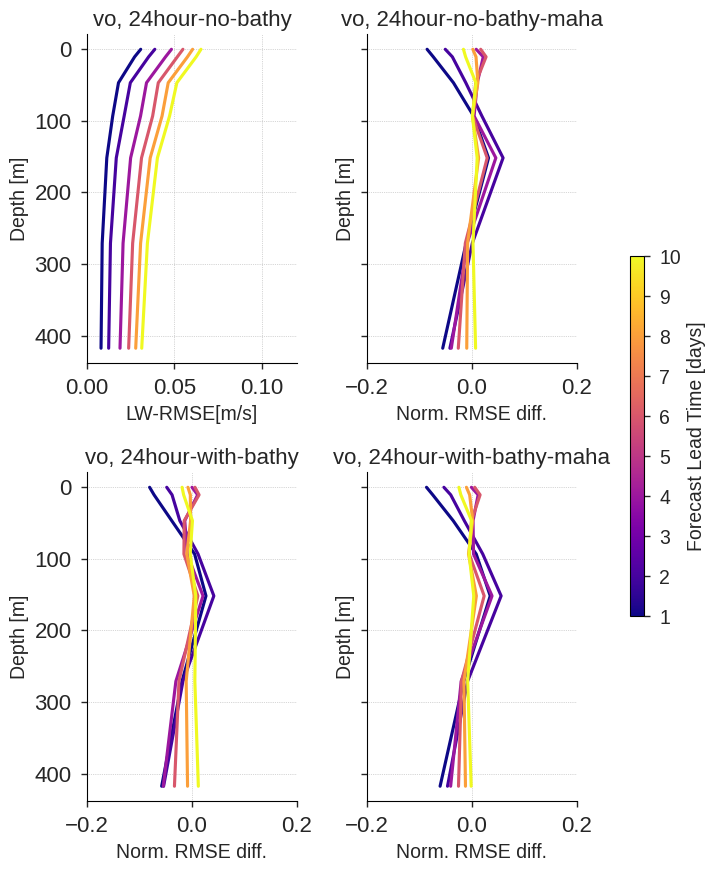

In [17]:
vars_3d.sort()
n_vars = len(vars_3d)
save_plot = True
apply_latitude_weighting = True

# Lead times for which to plot RMSE lines
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = mpl_cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

reference_model = models[0].replace(" ", "_")

for truth in truths:

    for var_name in vars_3d:
        
        ncols = 2
        nrows = math.ceil(n_vars / ncols)

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                                 figsize=(3.5 * ncols, 4.5 * nrows), sharey = "all",)
    
        print("var_name:", var_name)
            
        for j, model in enumerate(models):
            
            ax = axes[j// ncols][j % ncols]
            
            model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
            model_name = model.replace(" ", "_")

            # Compute RMSE, averaged over all non-lead_time/lat dims
            sqerr = sq_error[model_name][truth][var_name]
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))
            if model_name == reference_model:
                vmin=0; vmax=error_bounds[var_name]["vmax"]
                da_reference = da
                xlabel = "RMSE" + f"[{units.get(var_name)}]" 
                if apply_latitude_weighting:
                    xlabel = "LW-" + xlabel
            else:
                vmin=-0.2; vmax=0.2
                try:
                    da = (da - da_reference)/da_reference
                except AttributeError as e:
                    print(f"Make sure that the reference model is the first in the models list: {e}")                    
                xlabel = "Norm. RMSE diff."
                
            ax = plot_rmse_vs_depth(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10,
                    label=f"{descrip}",
                    xlabel=xlabel,
                    vmin=vmin, vmax=vmax,
                    days_to_plot=days_to_plot,
                    cmap=cmap,
                    norm=norm,
                    show_cbar=False,
                    apply_latitude_weighting=apply_latitude_weighting,
            )
            
        ax.invert_yaxis()
        
        # Remove any unused axes
        for idx in range(len(vars_3d), nrows * ncols):
            fig.delaxes(axes[idx // ncols][idx % ncols])

        plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right (90% width)
        
        # Add shared colorbar
        cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        sm = mpl_cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time (days)",
                            orientation="vertical", fraction=0.05, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(label="Forecast Lead Time [days]", size=14)

        #fig.suptitle(f"Intermodel comparison of RMSE vs depth for {var_name}", fontsize=14)

        # Save plot
        if save_plot:
            figname = f"Normalized_RMSE_diff_vs_depth_{var_name}_bathy-vs-nobathy_euclid-vs-maha_against_{truth}.jpeg"
            if apply_latitude_weighting:
                figname = f"LW-{figname}"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

## Plot depth vs lead time pcolormesh plot (with relative difference)

var_name: so


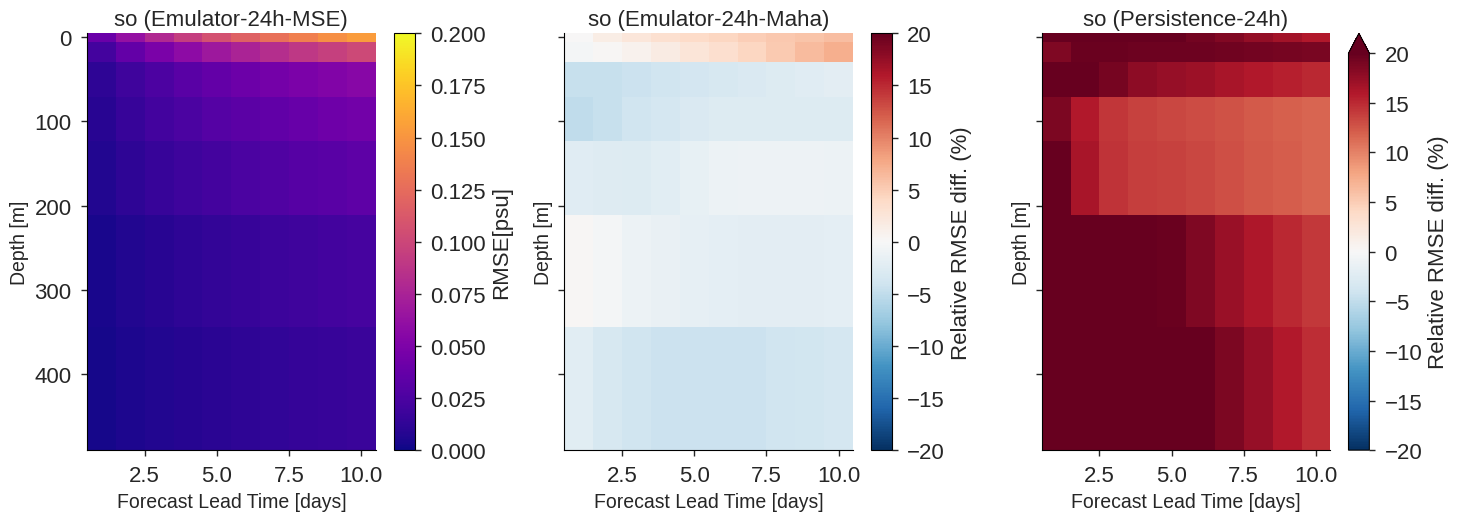

var_name: temp


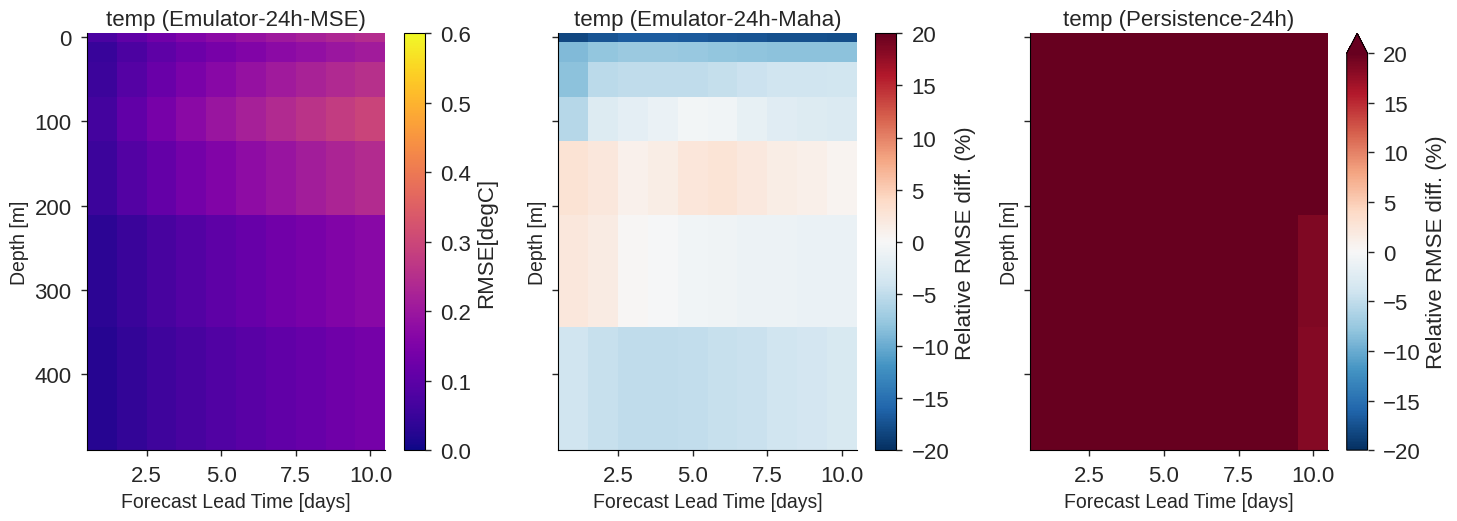

var_name: uo


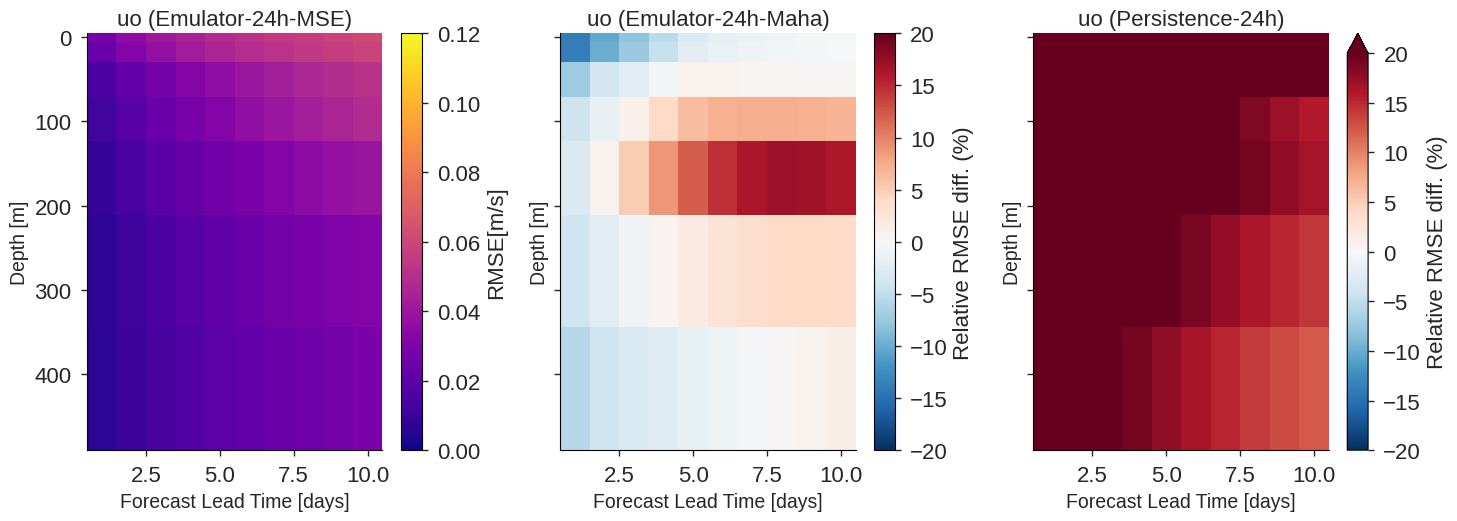

var_name: vo


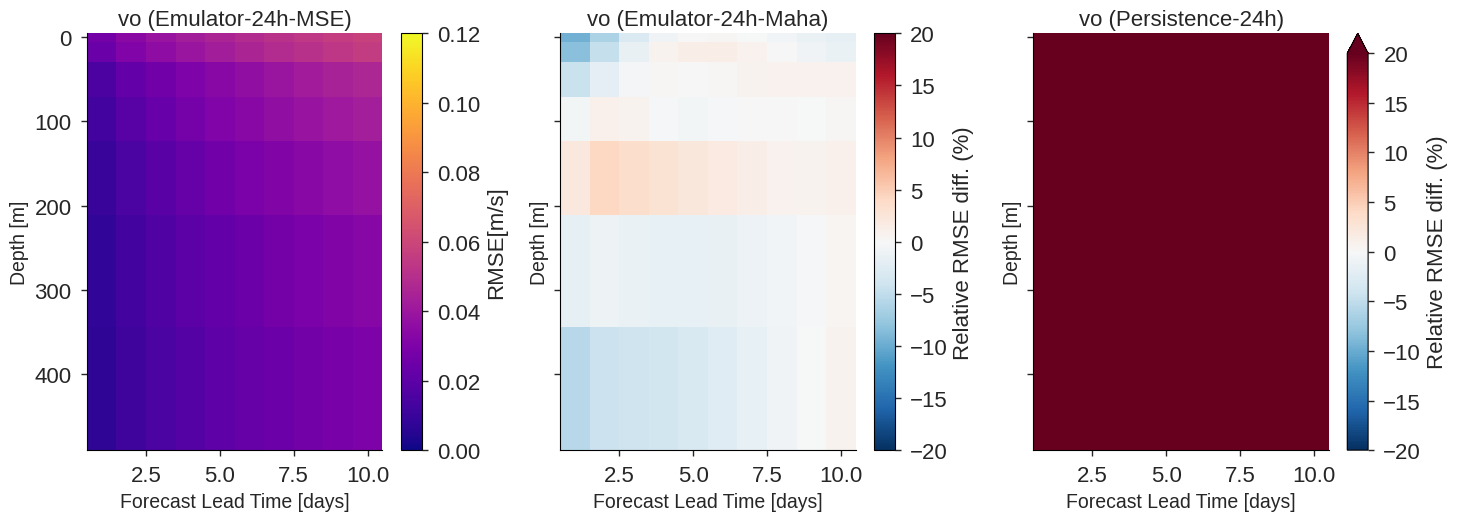

In [23]:
vars_3d.sort()
n_vars = len(vars_3d)
save_plot = True
apply_latitude_weighting = False

reference_model = MODELS_CONFIG[0]['name']

for truth in TRUTHS:

    for var_name in vars_3d:
        
        ncols = len(MODELS_CONFIG)
        nrows = 1

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                                 figsize=(5.5 * ncols, 5.5 * nrows), sharey = "all",)
    
        print("var_name:", var_name)
            
        for j, model in enumerate(MODELS_CONFIG):
            
            ax = axes[j]
            model_name = model['name']

            # Compute RMSE, averaged over all non-lead_time/lat dims
            sqerr = all_sq_error[model_name][truth][var_name]
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))
            if model_name == reference_model:
                vmin=0; vmax=error_bounds[var_name]["vmax"]
                da_reference = da
                clabel = "RMSE" + f"[{units.get(var_name)}]" 
                if apply_latitude_weighting:
                    clabel = "LW-" + xlabel
                cmap = mpl_cm.plasma
            else:
                vmin=-20; vmax=20
                try:
                    da = (da - da_reference)*100/da_reference
                except AttributeError as e:
                    print(f"Make sure that the reference model is the first in the models list: {e}")                    
                clabel = "Relative RMSE diff. (%)"
                cmap=mpl_cm.RdBu_r
                
            ax = plot_depth_vs_leadtime(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=model['timestep'],
                    label=f"{model['name']}",
                    vmin=vmin, vmax=vmax,
                    cmap=cmap,
                    show_title=True,
                    show_cbar=True,
                    clabel=clabel,
            )
        
        # Remove any unused axes
        for idx in range(len(vars_3d), nrows * ncols):
            fig.delaxes(axes[idx // ncols][idx % ncols])

        # improve the layout
        plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right (90% width)
        
        # Add shared colorbar
        #cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        #sm = mpl_cm.ScalarMappable(cmap=cmap, norm=norm)
        #sm.set_array([])
        #cbar = fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time (days)",
        #                    orientation="vertical", fraction=0.05, pad=0.02)
        #cbar.ax.tick_params(labelsize=14)
        #cbar.set_label(label="Forecast Lead Time [days]", size=14)

        #fig.suptitle(f"Intermodel comparison of RMSE vs depth for {var_name}", fontsize=14)

        # Save plot
        if save_plot:
            figname = f"RMSE_and_Normalized_RMSE_diff_vs_depth_{var_name}_MSE-vs-maha_against_{truth}_ocn-only_24h_1IC_coarseTop.png"
            if apply_latitude_weighting:
                figname = f"LW-{figname}"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

In [ ]:
vars_3d.sort()
n_vars = len(vars_3d)
save_plot = True
apply_latitude_weighting = True

# Lead times for which to plot RMSE lines
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = mpl_cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

reference_model = models[0].replace(" ", "_")

for truth in truths:

    for var_name in vars_3d:
        
        ncols = 2
        nrows = math.ceil(n_vars / ncols)

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                                 figsize=(3.5 * ncols, 4.5 * nrows), sharey = "all",)
    
        print("var_name:", var_name)
            
        for j, model in enumerate(models):
            
            ax = axes[j// ncols][j % ncols]
            
            model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
            model_name = model.replace(" ", "_")

            # Compute RMSE, averaged over all non-lead_time/lat dims
            sqerr = sq_error[model_name][truth][var_name]
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))
            if model_name == reference_model:
                vmin=0; vmax=error_bounds[var_name]["vmax"]
                da_reference = da
                xlabel = "RMSE" + f"[{units.get(var_name)}]" 
                if apply_latitude_weighting:
                    xlabel = "LW-" + xlabel
            else:
                vmin=-0.2; vmax=0.2
                try:
                    da = (da - da_reference)/da_reference
                except AttributeError as e:
                    print(f"Make sure that the reference model is the first in the models list: {e}")                    
                xlabel = "Norm. RMSE diff."
                
            ax = plot_rmse_vs_depth(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10,
                    label=f"{descrip}",
                    xlabel=xlabel,
                    vmin=vmin, vmax=vmax,
                    days_to_plot=days_to_plot,
                    cmap=cmap,
                    norm=norm,
                    show_cbar=False,
                    apply_latitude_weighting=apply_latitude_weighting,
            )
            
        ax.invert_yaxis()
        
        # Remove any unused axes
        for idx in range(len(vars_3d), nrows * ncols):
            fig.delaxes(axes[idx // ncols][idx % ncols])

        plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right (90% width)
        
        # Add shared colorbar
        cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        sm = mpl_cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time (days)",
                            orientation="vertical", fraction=0.05, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(label="Forecast Lead Time [days]", size=14)

        #fig.suptitle(f"Intermodel comparison of RMSE vs depth for {var_name}", fontsize=14)

        # Save plot
        if save_plot:
            figname = f"Normalized_RMSE_diff_vs_depth_{var_name}_bathy-vs-nobathy_euclid-vs-maha_against_{truth}.jpeg"
            if apply_latitude_weighting:
                figname = f"LW-{figname}"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

## Error as a function of the latitude for selected vertical levels

In [17]:
# update error bounds
error_bounds["so"]["vmax"] = [1, 0.3, 0.2, 0.05]   
error_bounds["temp"]["vmax"] = [1.0, 1.0, 1.0, 0.5] 
error_bounds["uo"]["vmax"] = [0.3, 0.3, 0.3, 0.1]
error_bounds["vo"]["vmax"] = [0.3, 0.2, 0.2, 0.1] 

var: so
level: 0


NameError: name 'plot_rmse_vs_latitude' is not defined

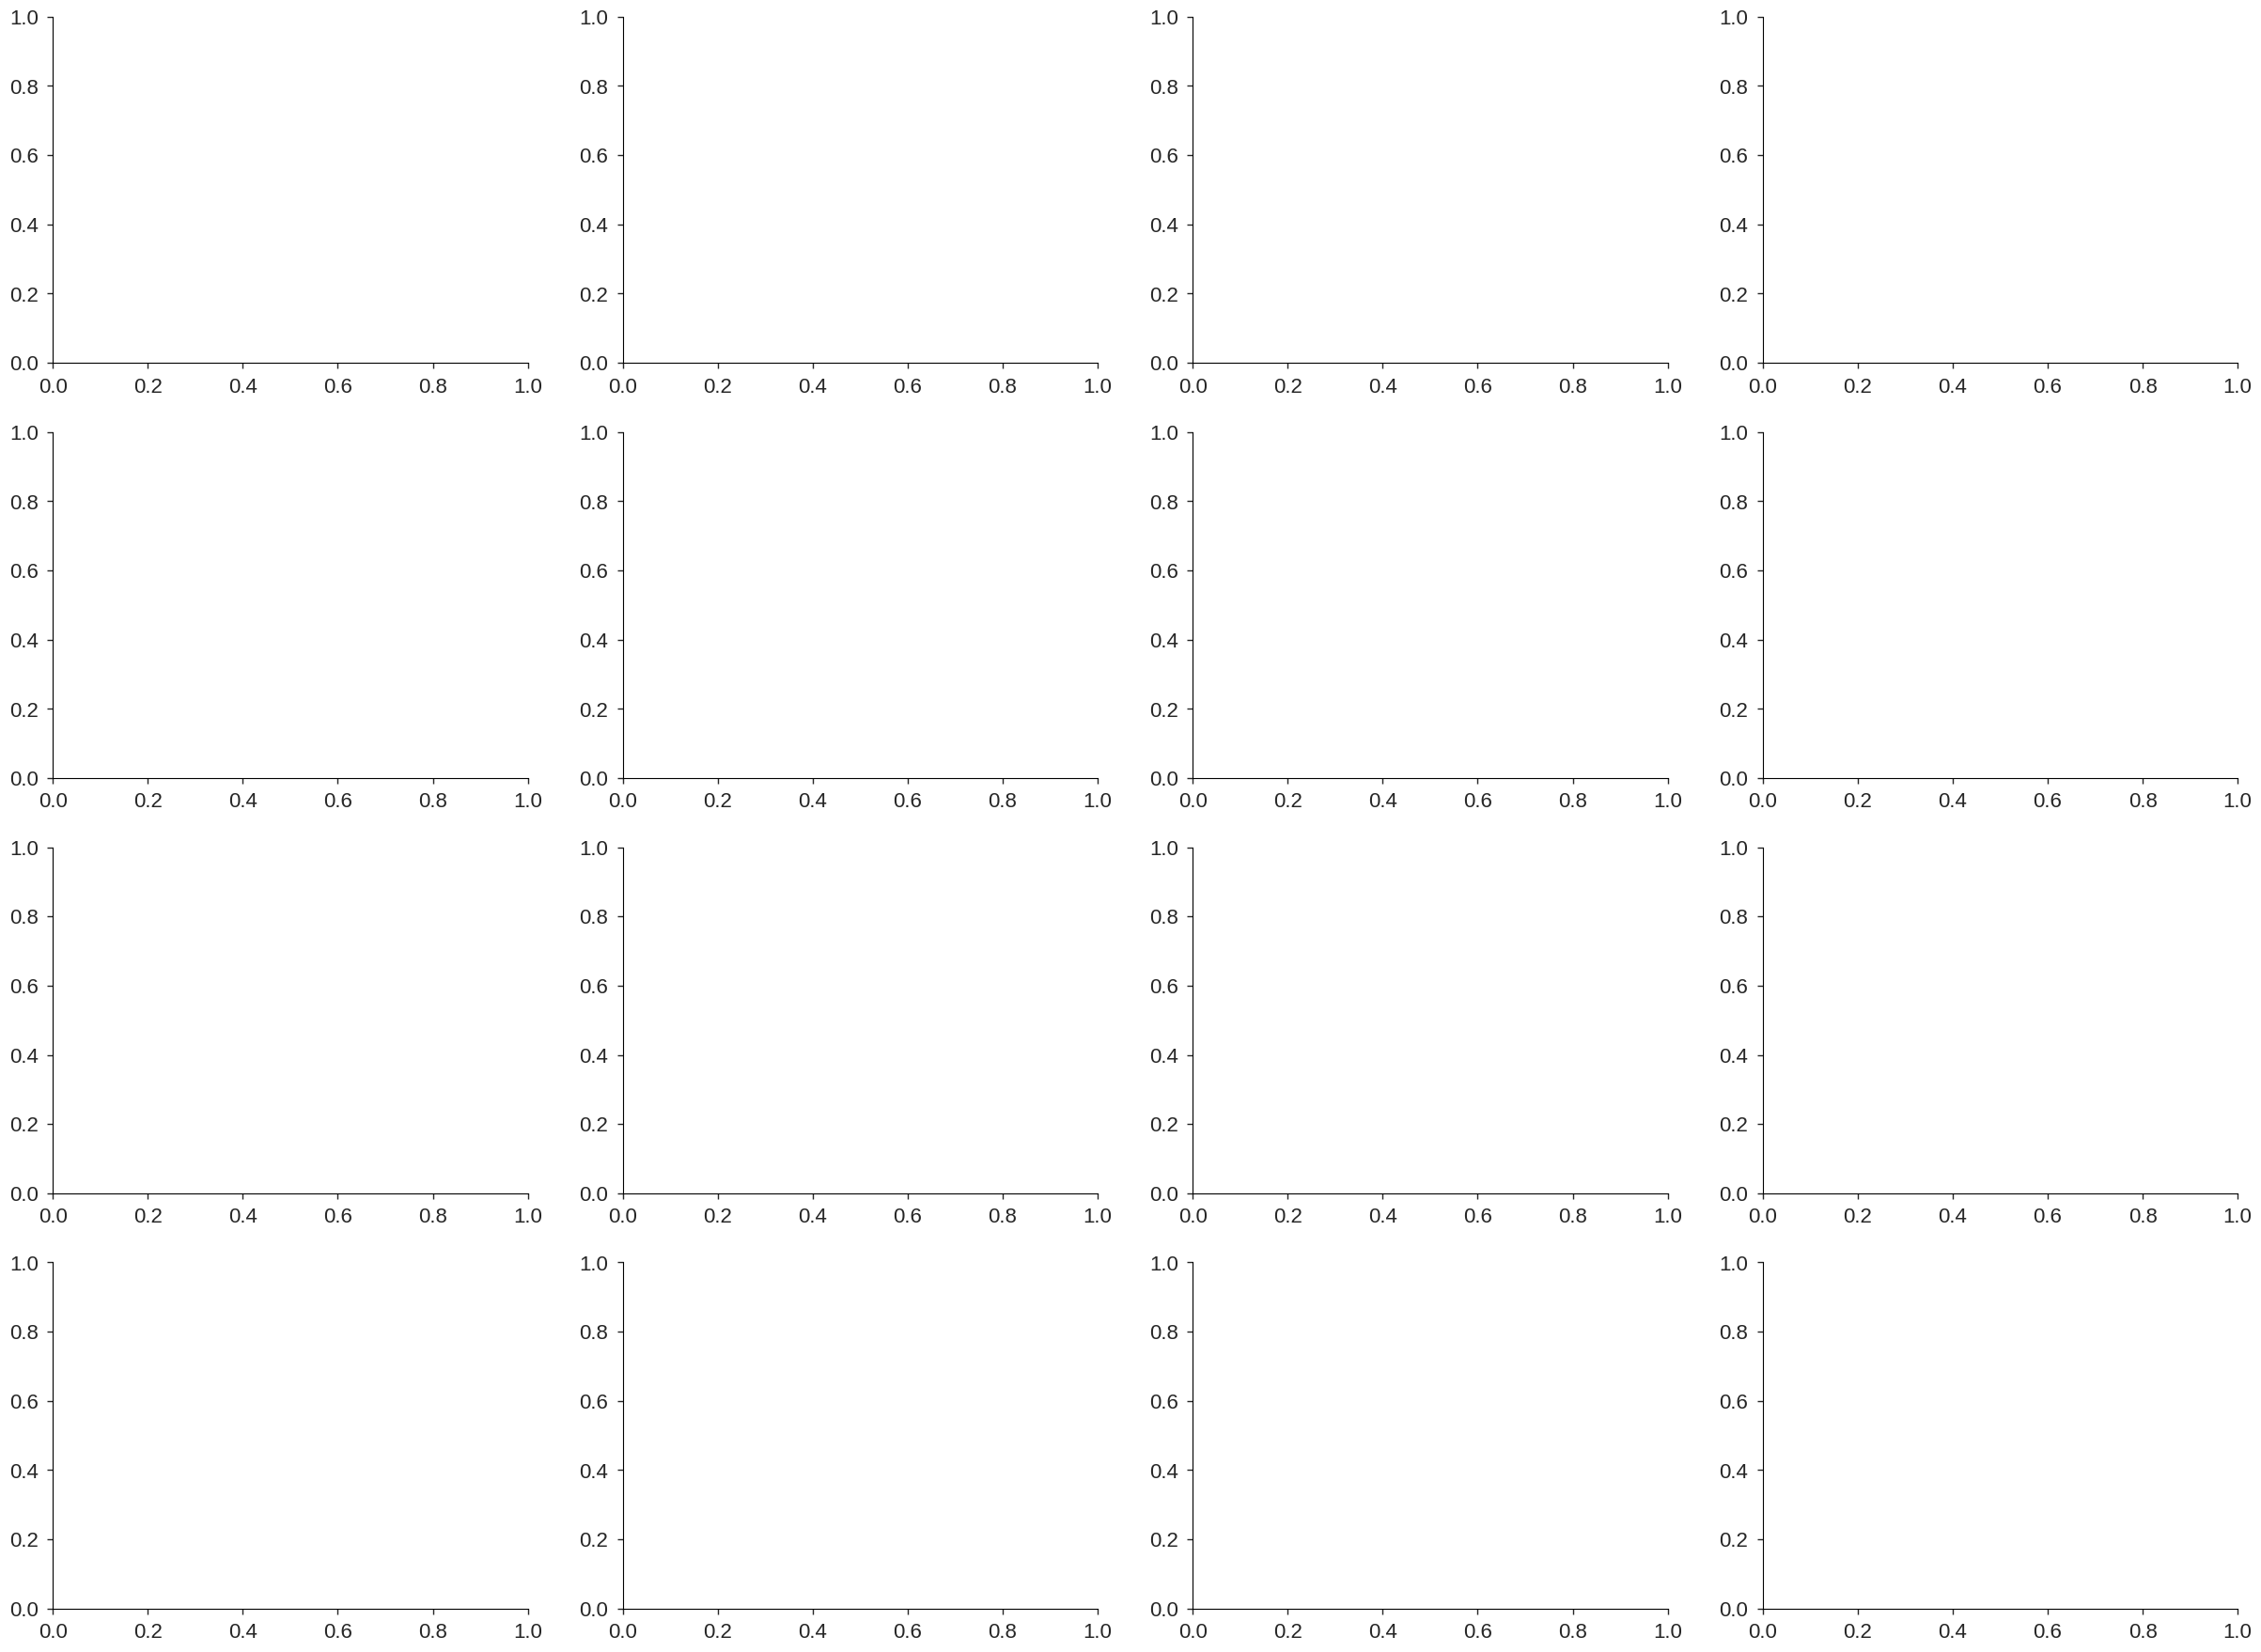

In [10]:
vars_3d.sort()
levels = [0, 50, 100, 400]
n_vars = len(vars_3d)
save_plot = True

# Prepare color gradient
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for model in models:
    model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
    model_name = model.replace(" ", "_")

    for truth in truths:
        fig, axes = plt.subplots(nrows=len(levels), ncols=n_vars,
                                 figsize=(7.5 * n_vars, 5.5 * len(levels)),
                                 squeeze=False)

        for j, var_name in enumerate(vars_3d):
            print("var:", var_name)
            sqerr = sq_error[model_name][truth][var_name]
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l", "lat"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            for i, level in enumerate(levels):
                print("level:", level)
                da_lev = da.sel(z_l=level, method="nearest")
                plot_rmse_vs_latitude(
                    axes[i][j], 
                    da_lev, 
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10, 
                    label=f"{descrip}",
                    vmax=error_bounds[var_name]["vmax"][i],
                    days_to_plot=days_to_plot,
                    cmap=cmap, 
                    norm=norm, 
                    show_cbar=False,
                )
                if j==0:
                    axes[i][j].set_ylabel(f"z_l={da_lev.z_l.values:.2f}m", size=12)

        # Add shared colorbar
        fig.subplots_adjust(right=0.85)
        cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7]) # [left, bottom, width, height]
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time [days]",
                     orientation="vertical", fraction=0.05, pad=0.02)

        fig.suptitle(f"RMSE vs Latitude for {model_name} vs {truth}", fontsize=14)

        #plt.tight_layout()
        if save_plot:
            fname = f"./figures/RMSE_vs_latitude_{model_name}.jpeg"
            plt.savefig(fname, dpi=300)
        plt.show()

## Separate figure for each variable. Each figure would contain columns corresponding to the model compared and the rows would correspond to the levels.

In [17]:
# update error bounds
error_bounds["so"]["vmax"] = [1, 0.3, 0.2, 0.05]   
error_bounds["temp"]["vmax"] = [1.0, 1.0, 1.0, 0.5] 
error_bounds["uo"]["vmax"] = [0.3, 0.3, 0.3, 0.1]
error_bounds["vo"]["vmax"] = [0.3, 0.2, 0.2, 0.1] 

var: so
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


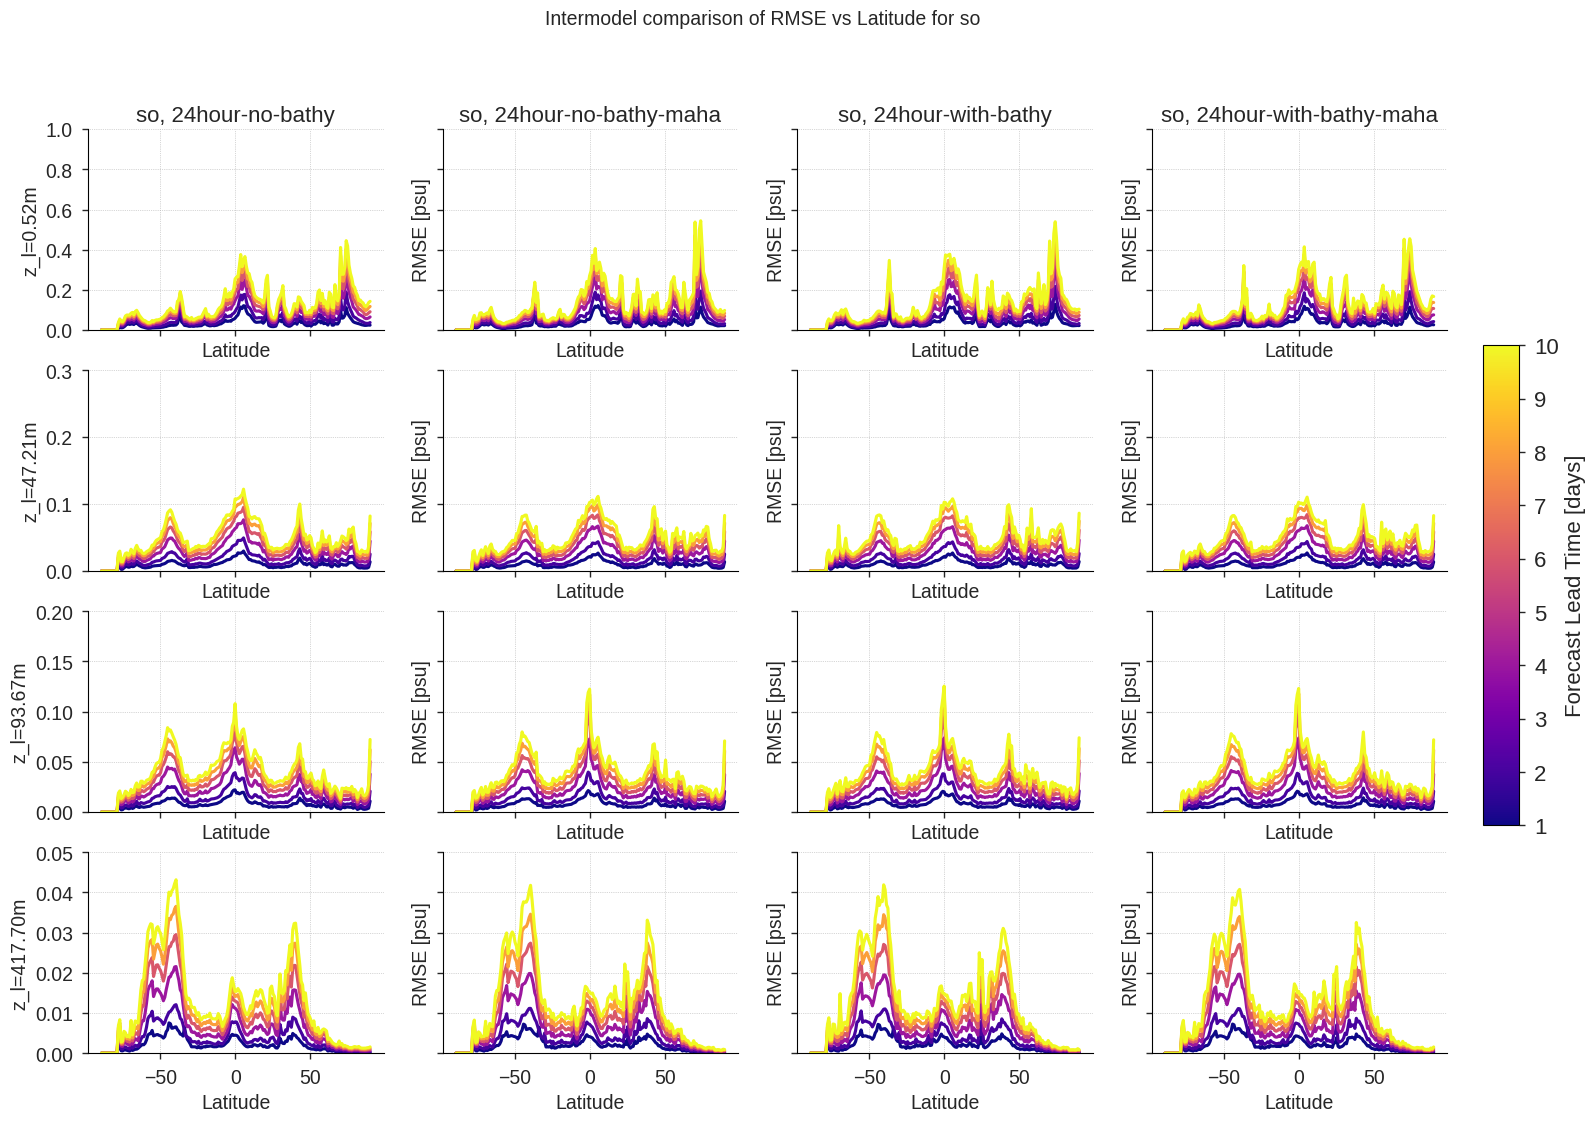

var: temp
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


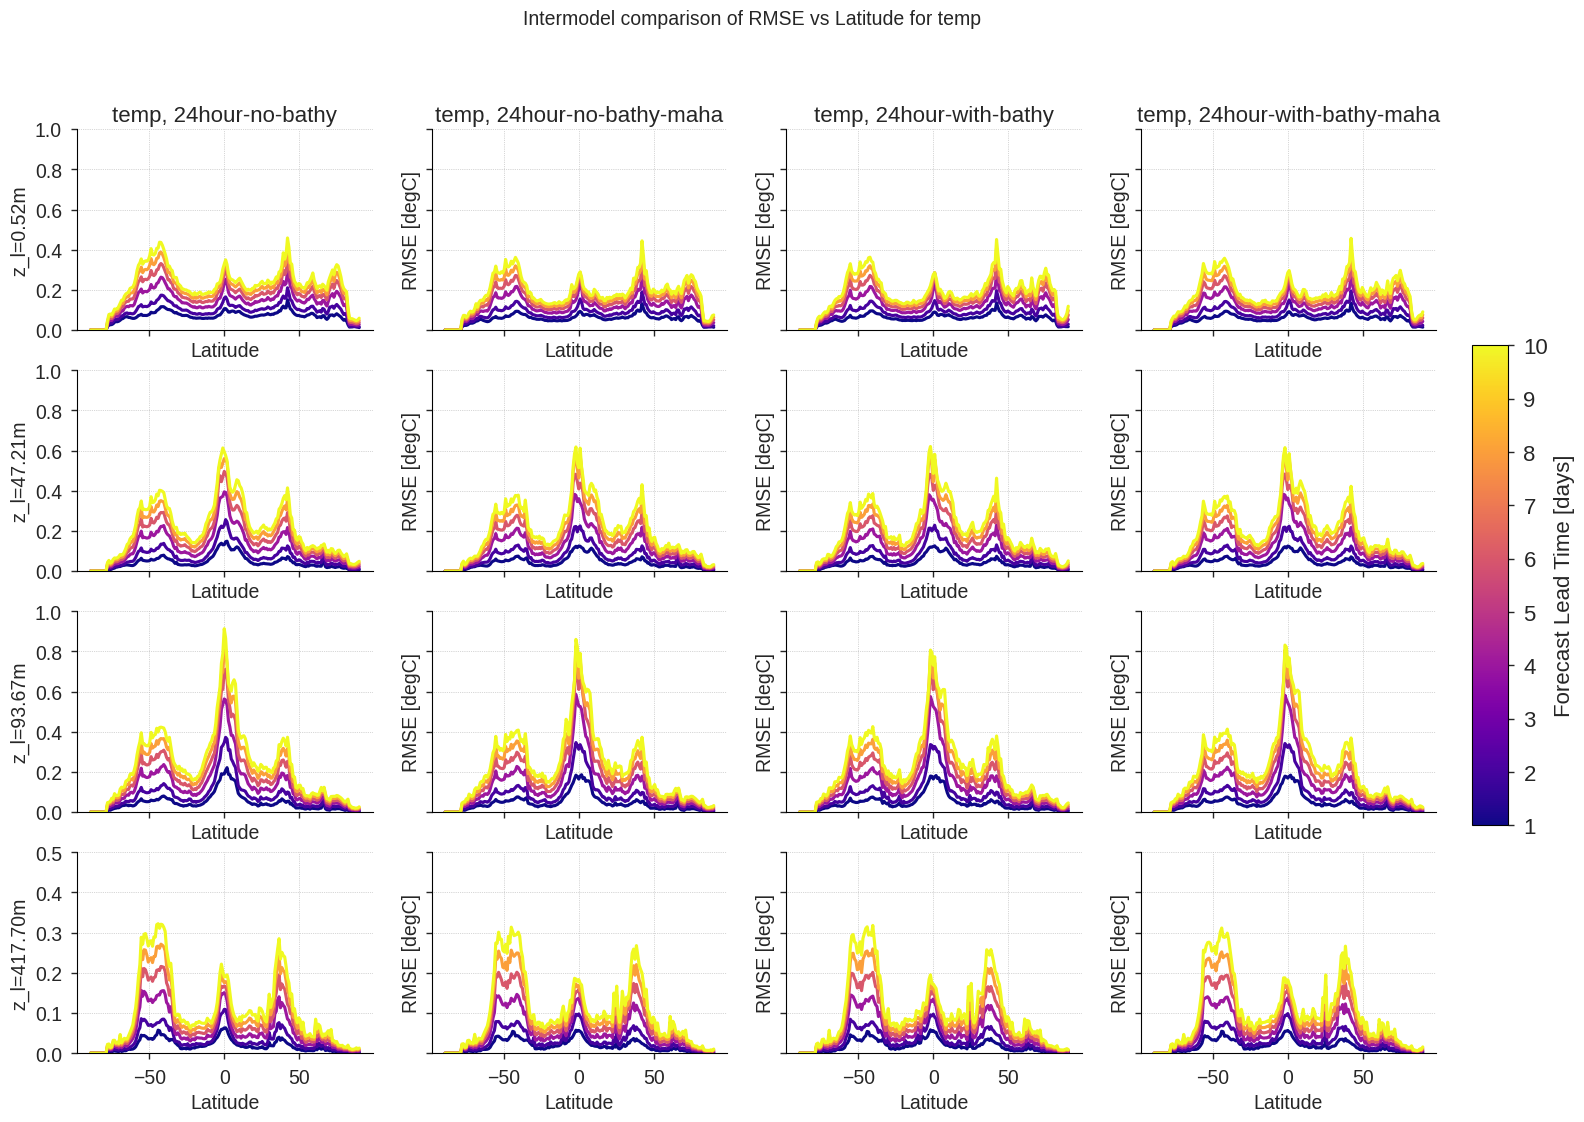

var: uo
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


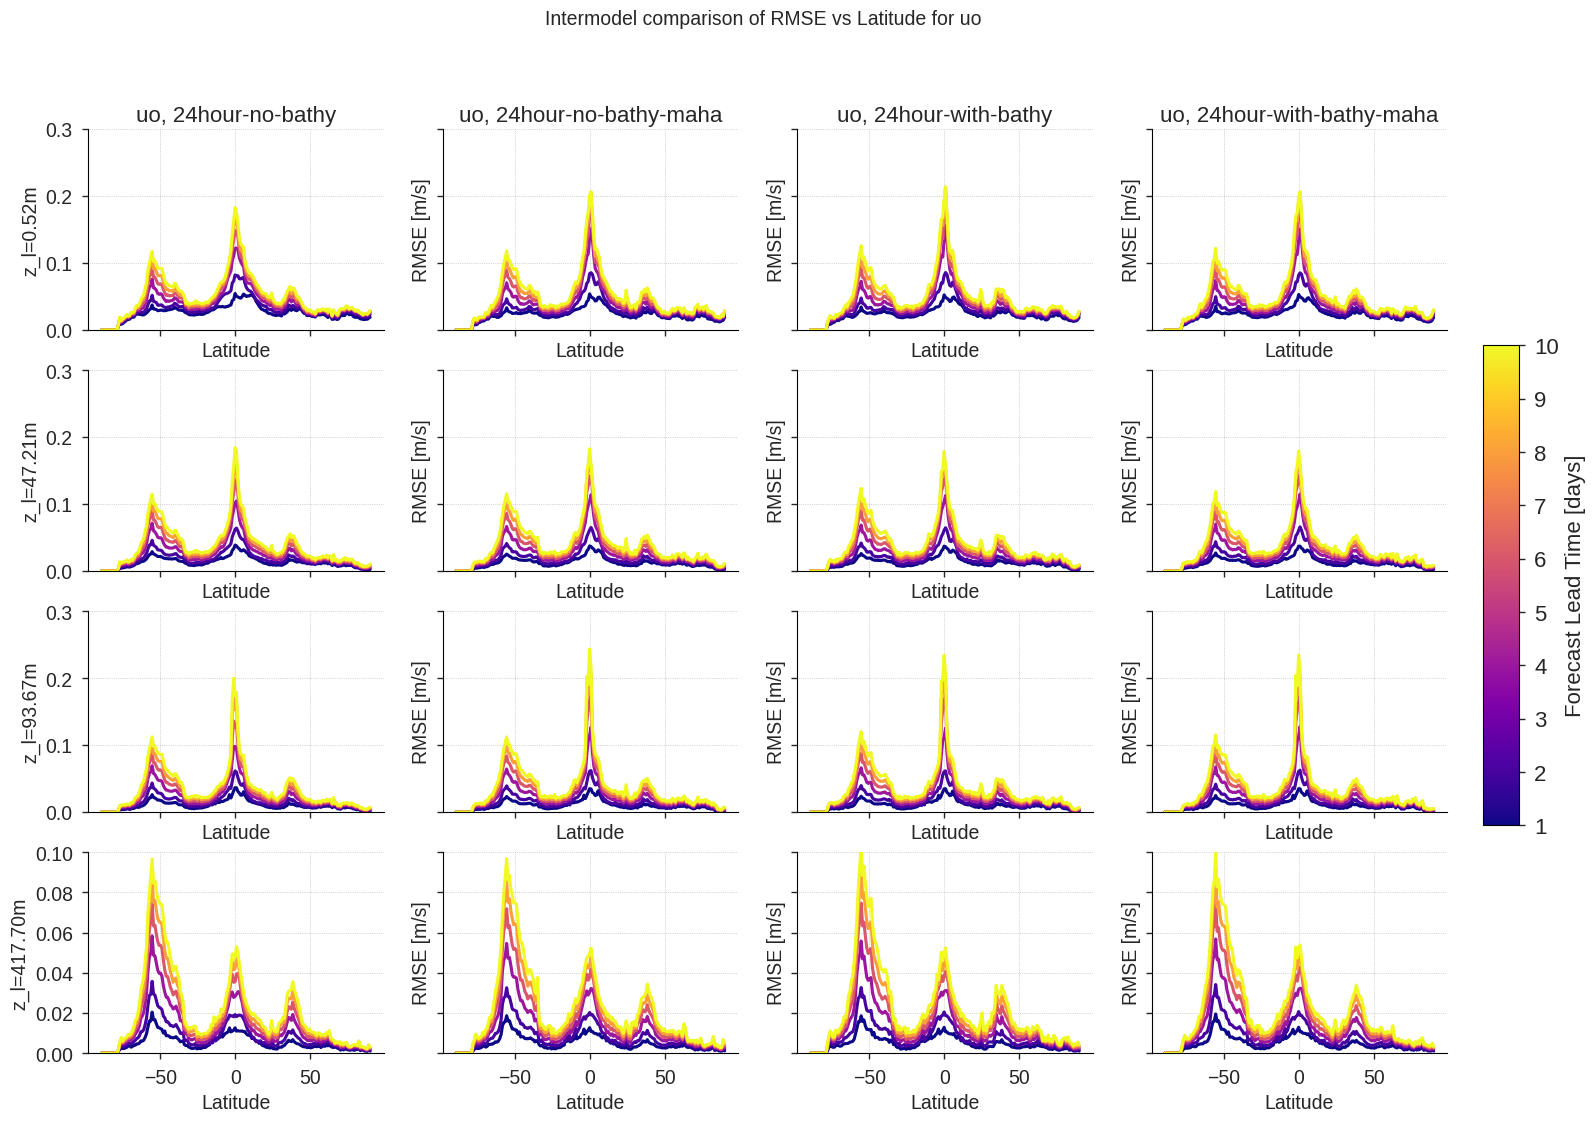

var: vo
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


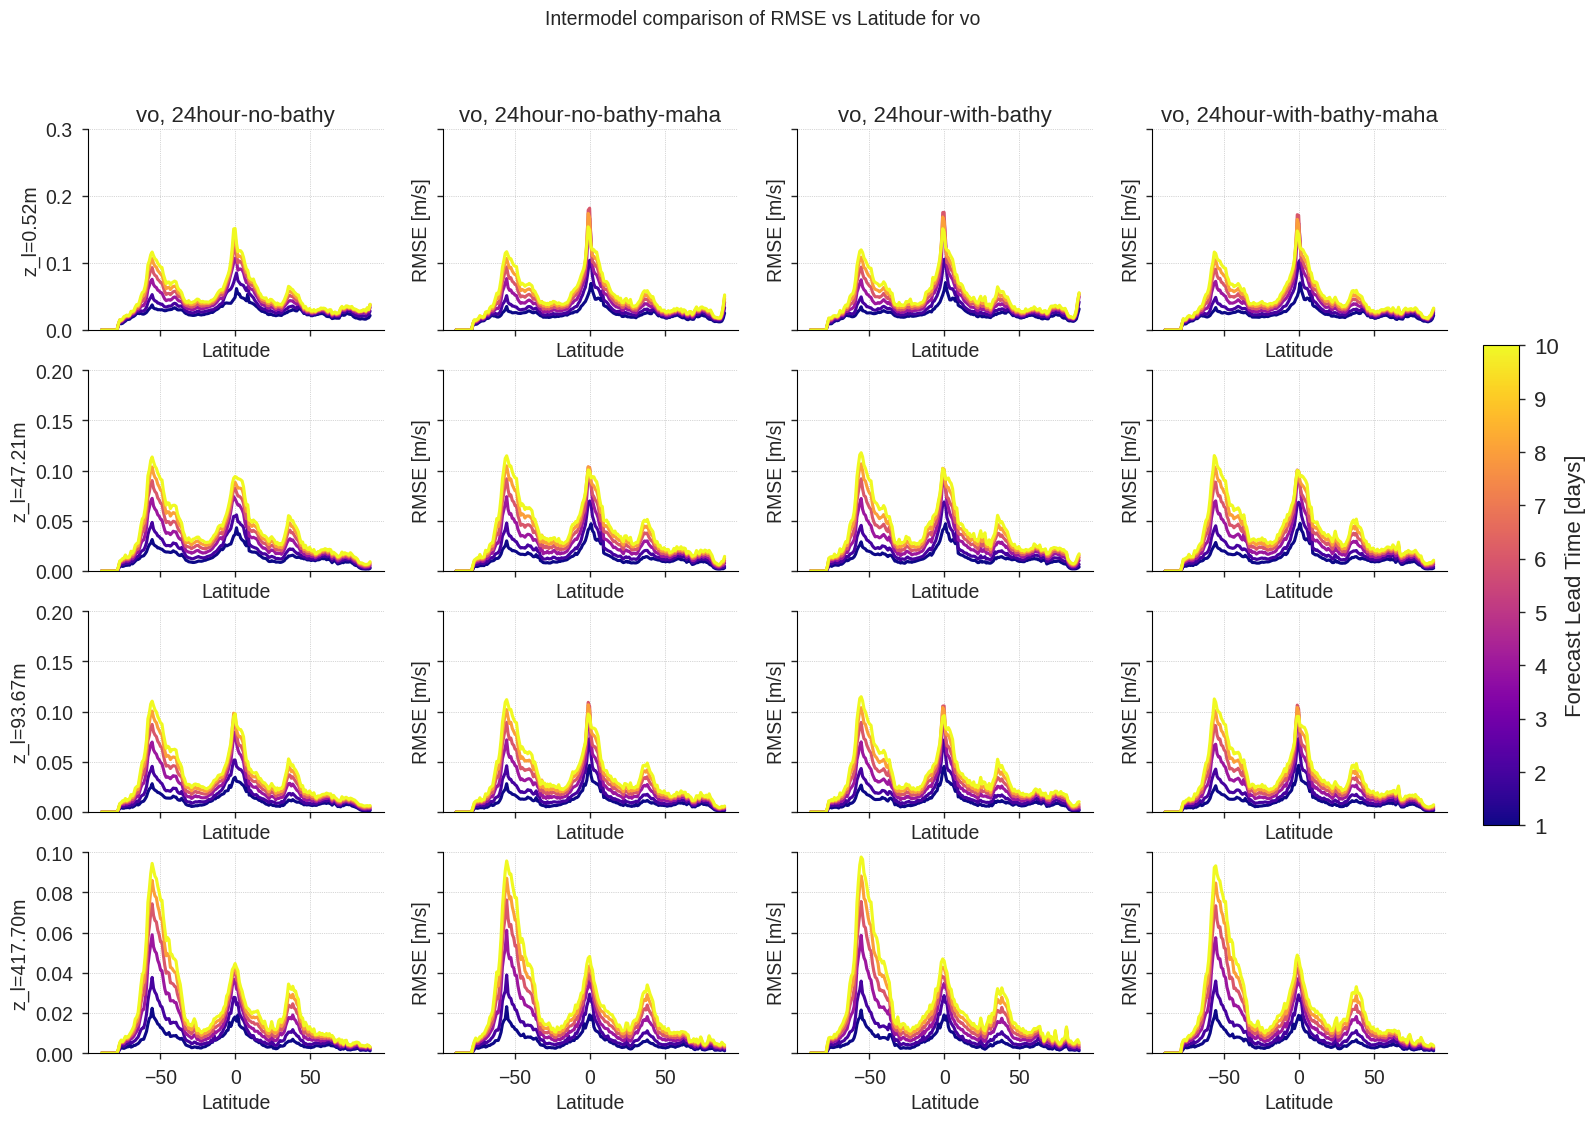

In [19]:
vars_3d.sort()
levels = [0, 50, 100, 400]
n_vars = len(vars_3d)
save_plot = True

# Prepare color gradient
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = mpl_cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for truth in truths:

    for var_name in vars_3d:
        fig, axes = plt.subplots(nrows=len(levels), ncols=len(models),
                                 figsize=(4.5 * len(models), 3 * len(levels)),
                                 sharey="row", sharex="all", squeeze=False)
        print("var:", var_name)

        for j, model in enumerate(models):
            model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
            model_name = model.replace(" ", "_")
            sqerr = sq_error[model_name][truth][var_name]
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l", "lat"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            for i, level in enumerate(levels):
                print("level:", level)
                da_lev = da.sel(z_l=level, method="nearest")
                plot_rmse_vs_latitude(
                    axes[i][j], 
                    da_lev, 
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10, 
                    label=f"{descrip}",
                    vmax=error_bounds[var_name]["vmax"][i],
                    days_to_plot=days_to_plot,
                    cmap=cmap, 
                    norm=norm, 
                    show_cbar=False,
                    show_title=True if i == 0 else False,
                )
                if j == 0:
                    axes[i][j].set_ylabel(f"z_l={da_lev.z_l.values:.2f}m",)

        # Add shared colorbar
        fig.subplots_adjust(right=0.88)
        cbar_ax = fig.add_axes([0.9, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        sm = mpl_cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time [days]",
                     orientation="vertical", fraction=0.05, pad=0.02)

        fig.suptitle(f"Intermodel comparison of RMSE vs Latitude for {var_name}", fontsize=14)

        #plt.tight_layout()
        if save_plot:
            fname = f"./figures/RMSE_vs_latitude_{var_name}_ocn_only_{model_time_step}_bathy-vs-nobathy_euclid-vs-maha_against_{truth}.jpeg"
            plt.savefig(fname, dpi=300)
        plt.show()

## Same as above, but plot normalized RMSE diff (RMSE_model - RMSE_ref)/RMSE_ref

var: temp
level: 0
level: 0


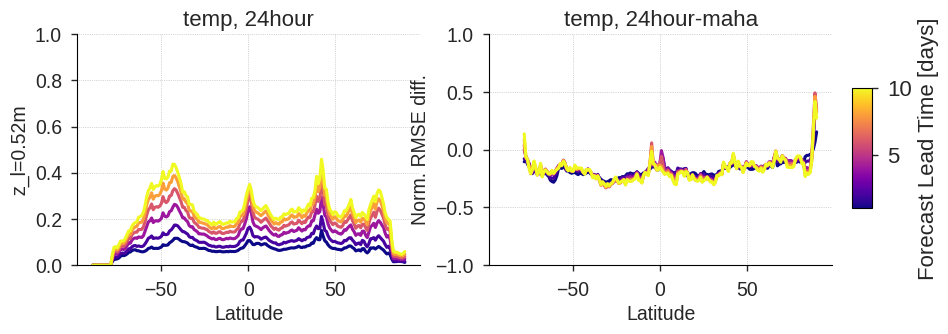

In [22]:
#vars_3d.sort()
vars_3d = ["temp"]
levels = [0,]
n_vars = len(vars_3d)
save_plot = True

# Prepare color gradient
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = mpl_cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

reference_model = models[0].replace(" ", "_")

for truth in truths:

    for var_name in vars_3d:
        fig, axes = plt.subplots(nrows=len(levels), ncols=len(models),
                                 figsize=(5 * len(models), 3 * len(levels)),
                                 sharex="all", squeeze=False)
        print("var:", var_name)

        for j, model in enumerate(models):
            model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
            model_name = model.replace(" ", "_")
            sqerr = sq_error[model_name][truth][var_name]
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l", "lat"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            if model_name == reference_model:
                da_reference = da
                ylabel = "RMSE [m]"
            else:
                vmin=-1; vmax=1
                try:
                    da = (da - da_reference)/da_reference
                except AttributeError as e:
                    print(f"Make sure that the reference model is the first in the models list: {e}")                    
                ylabel = "Norm. RMSE diff."
                
            for i, level in enumerate(levels):
                print("level:", level)
                if model_name == reference_model:
                    vmin=0; vmax=error_bounds[var_name]["vmax"][i]
                else:
                    vmin=-1; vmax=1
                    
                da_lev = da.sel(z_l=level, method="nearest")
                plot_rmse_vs_latitude(
                    axes[i][j], 
                    da_lev, 
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10, 
                    label=f"{descrip}",
                    ylabel = ylabel,
                    vmin=vmin,
                    vmax=vmax,
                    days_to_plot=days_to_plot,
                    cmap=cmap, 
                    norm=norm, 
                    show_cbar=False,
                    show_title=True if i == 0 else False,
                )
                if j == 0:
                    axes[i][j].set_ylabel(f"z_l={da_lev.z_l.values:.2f}m",)

        # Add shared colorbar
        fig.subplots_adjust(right=0.88)
        cbar_ax = fig.add_axes([0.9, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        sm = mpl_cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time [days]",
                     orientation="vertical", fraction=0.05, pad=0.02)

        #fig.suptitle(f"Intermodel comparison of RMSE vs Latitude for {var_name}", fontsize=14)

        #plt.tight_layout()
        if save_plot:
            fname = f"./figures/Norm_RMSE_diff_vs_latitude_{var_name}_ocn_only_{model_time_step}_euclid-vs-maha_against_{truth}.jpeg"
            plt.savefig(fname, dpi=300)
        plt.show()